In [1]:
using Revise
# includet("functions.jl")
includet("Julia/NHQRM/functions.jl")
using .MyFunctions

using LinearAlgebra
using QuantumToolbox
using ProgressMeter
using CairoMakie
# import Pkg
# Pkg.activate(".")

CairoMakie.activate!(type = "png", px_per_unit = 2)

set_theme!(merge(theme_latexfonts(),
    Theme(
        size           = (800, 500),
        fontsize       = 20,
        figure_padding = 14,
        Axis = (
            xgridvisible = false,
            ygridvisible = false,
            xtickalign   = 0,
            ytickalign   = 0,
            xlabelsize     = 24,
            ylabelsize     = 24,
            xticklabelsize = 20,
            yticklabelsize = 20,
        ),
        Lines = (linewidth = 3,),
    ),
))

# Hermitian case

In [2]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 1

vars = (ωa=ωa, ωb=ωb, Nc=Nc, N=N);

In [3]:
g_list = range(1e-3, 1.5, 600) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:12


 12.778846 seconds (57.57 M allocations: 3.832 GiB, 8.87% gc time, 139 lock conflicts, 3025.67% compilation time: <1% of which was recompilation)
  0.297217 seconds (975.48 k allocations: 561.262 MiB, 30.32% gc time, 1136.95% compilation time)
  3.126934 seconds (16.23 M allocations: 1.575 GiB, 7.34% gc time, 2929.78% compilation time)


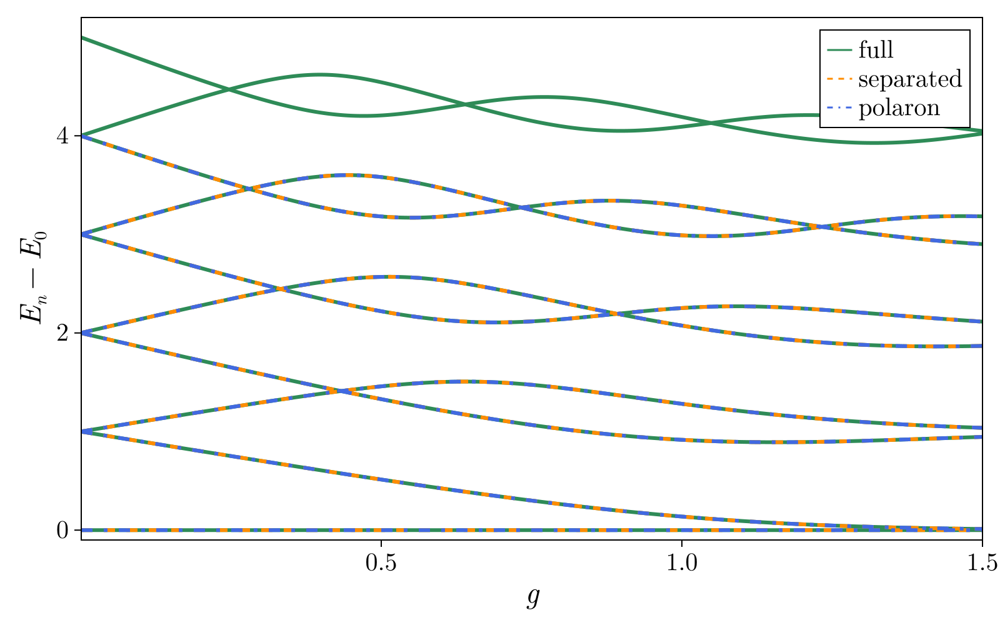

In [4]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

# save("QRM_energies_1at.pdf", fig; px_per_unit = 3)
fig

# Non-Hermitian case

This case works only when the coupling strengths between the qubit and oscillator, as well as between the system and the external environment are weak. In particular, by neglecting the quantum jumps, we obtain the non-Hermitian Hamiltonian generating the post-selected evolution.

In [2]:
P_NH = (g = 1.0, ωa = 1.0, ωb = 1.0, Nc = 80, N = 1, γa = 0.0, γb = 0.0)

_vars(p) = (ωa = p.ωa, ωb = p.ωb, Nc = p.Nc, N = p.N, γa = p.γa, γb = p.γb)
nh_block(p, wh) = (r = parity_blocks_NH(p.g, _vars(p)); wh === :even ? r[1] : r[2])
withp(p; kw...) = merge(p, (; kw...))
set2(p, k1, x1, k2, x2) = merge(p, NamedTuple{(k1, k2)}((x1, x2)))

function pair_gap_overlap(H; kmax = 10)
    F = eigen(H)
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    
    k = min(kmax, length(vals))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(vals[a] - vals[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return m, abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
end

function closest_pair(p, wh; kmax = 10)
    v = sort(eigvals(nh_block(p, wh)), by = real)

    k = min(kmax, length(v))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(v[a] - v[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return pa, pb
end

d2_pair(p, k1, k2, x1, x2, wh, pa, pb) = (v = sort(eigvals(nh_block(set2(p, k1, x1, k2, x2), wh)), by = real); (v[pa] - v[pb])^2)

function newton_ep(p, k1, k2, wh, pa, pb; iters = 60, step = 1e-6)
    x = [getfield(p, k1), getfield(p, k2)]
    for _ in 1:iters
        f  = d2_pair(p, k1, k2, x[1], x[2], wh, pa, pb)
        f1 = (d2_pair(p, k1, k2, x[1]+step, x[2], wh, pa, pb) - f) / step
        f2 = (d2_pair(p, k1, k2, x[1], x[2]+step, wh, pa, pb) - f) / step
        dx = [real(f1) real(f2); imag(f1) imag(f2)] \ [-real(f); -imag(f)]
        s  = min(1.0, 0.3 / (norm(dx) + step^2))
        x .+= s .* dx
        x[1] = clamp(x[1], 0.0, 3.0); x[2] = clamp(x[2], 0.0, 3.0)
        norm(s .* dx) < 1e-13 && break
    end
    return set2(p, k1, x[1], k2, x[2])
end

function ep_check(p, wh, pa, pb)
    F = eigen(nh_block(p, wh))
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    gap = abs(vals[pa] - vals[pb])
    ov  = abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
    return gap, ov
end

ep_check (generic function with 1 method)

## Presence of EPs varying $g$ and $\gamma_a$ ($\gamma_b = 0$)

We study the presence of EPs by firstly scanning a 2D colormap, and subsequently (sitting on a specific EP) the energy levels and eigenvectors. We notice that, even if the parameters should change between EPs, it is possible to see almost all the EPs on the energy spectrum, since they are localed almost on the line $\gamma_a =$ cost. All the EPs found in the USC are most likely artifacts. Nonetheless, genuine EPs can be found in the weak coupling regime corresponding to the transition between weak and strong coupling.

In [22]:
gs = range(0.2, 1.5, 200) |> collect
γs = range(0.05, 1.0, 200) |> collect

GAP = fill(Inf, length(gs), length(γs))
OVL = zeros(length(gs), length(γs))
PAR = fill(:even, length(gs), length(γs))

Prog = Progress(length(gs))
Threads.@threads for i in eachindex(gs)
    for j in eachindex(γs)
        g = gs[i]
        γa = γs[j]
        He, Ho = parity_blocks_NH(g, _vars(withp(P_NH; g = g, γa = γa)))
        me, oe = pair_gap_overlap(He)
        mo, oo = pair_gap_overlap(Ho)
        if me <= mo
            GAP[i, j] = me
            OVL[i, j] = oe
            PAR[i, j] = :even
        else
            GAP[i, j] = mo
            OVL[i, j] = oo
            PAR[i, j] = :odd
        end
    end
    next!(Prog)
end

eps_found = NamedTuple[]
Prog = Progress(length(gs) - 2)
Threads.@threads for i in 2:length(gs)-1
    for j in 2:length(γs)-1
        if all(GAP[i, j] <= GAP[i+di, j+dj] for di in -1:1, dj in -1:1)
            wh = PAR[i, j]
            pseed = withp(P_NH; g = gs[i], γa = γs[j])
            pa, pb = closest_pair(pseed, wh)
            pe = newton_ep(pseed, :g, :γa, wh, pa, pb)
            gap, ov = ep_check(pe, wh, pa, pb)
            if gap < 1e-5 && ov > 1 - 1e-6
                e = (g = round(pe.g, digits = 4), γa = round(pe.γa, digits = 4), parity = wh, gap = gap, ov = ov, energy_levels = (pa, pb))
                any(u -> abs(u.g - e.g) < 1e-2 && abs(u.γa - e.γa) < 1e-2, eps_found) || push!(eps_found, e)
            end
        end
    end
    next!(Prog)
end

println("exact EPs found (γb = $(P_NH.γb)): ", length(eps_found))
foreach(e -> println("  g = ", e.g, "   γa = ", e.γa, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2), "   1-overlap = ", round(1 - e.ov, sigdigits = 2)), eps_found)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:37
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


exact EPs found (γb = 0.0): 22
  g = 0.4361   γa = 0.5835   odd   (6, 7)   gap = 2.8e-7   1-overlap = 7.0e-14
  g = 0.3552   γa = 0.5832   even   (9, 10)   gap = 2.8e-7   1-overlap = 7.1e-14
  g = 1.1049   γa = 0.3272   odd   (6, 7)   gap = 1.8e-7   1-overlap = 1.7e-14
  g = 0.8411   γa = 0.4137   odd   (5, 6)   gap = 2.4e-7   1-overlap = 3.8e-14
  g = 0.5372   γa = 0.5843   odd   (4, 5)   gap = 1.7e-7   1-overlap = 2.5e-14
  g = 0.9542   γa = 0.4174   even   (4, 5)   gap = 1.8e-7   1-overlap = 2.0e-14
  g = 0.7027   γa = 0.4109   odd   (7, 8)   gap = 1.8e-7   1-overlap = 2.2e-14
  g = 0.4787   γa = 0.5838   even   (5, 6)   gap = 1.7e-7   1-overlap = 2.7e-14
  g = 1.2326   γa = 0.3323   even   (5, 6)   gap = 1.6e-7   1-overlap = 1.3e-14
  g = 1.3413   γa = 0.2745   odd   (7, 8)   gap = 3.0e-7   1-overlap = 4.0e-14
  g = 0.4033   γa = 0.5834   even   (7, 8)   gap = 6.2e-8   1-overlap = 3.4e-15
  g = 1.4786   γa = 0.2804   even   (6, 7)   gap = 2.5e-7   1-overlap = 2.6e-14
  g = 0.6555  

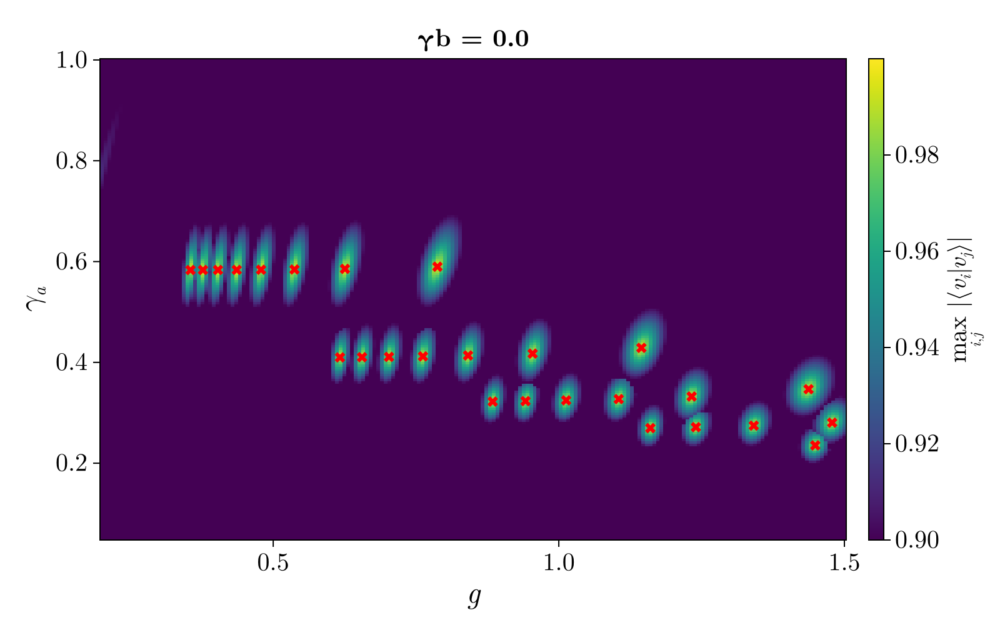

In [ ]:
fig_map = Figure(size = (800, 500))

ax = Axis(fig_map[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "γb = $(P_NH.γb)")
hm = heatmap!(ax, gs, γs, OVL; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_map[1, 2], hm; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(ax, [e.g for e in eps_found], [e.γa for e in eps_found]; color = :red, marker = :xcross, markersize = 12)

# save("ep_map.png", fig_map; px_per_unit = 3)
fig_map

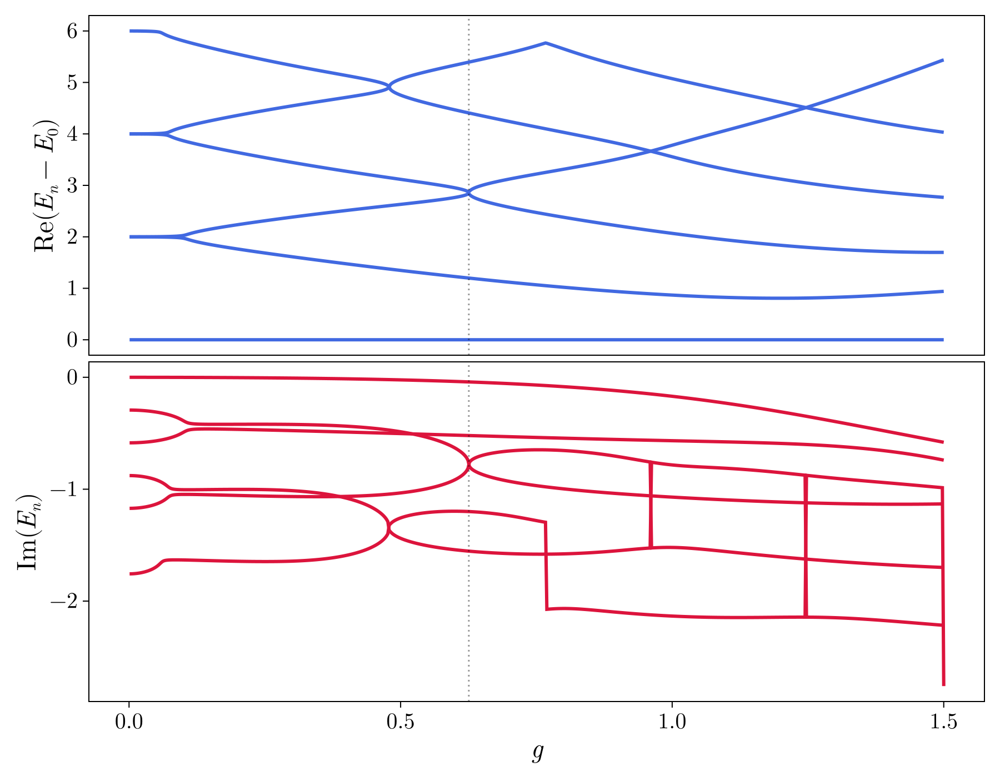

In [ ]:
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow] .- real(v[1])
end


fig_cut = Figure(size = (900, 700))

a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n - E_0)")
for n in 1:kshow
    lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue)
end

a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow
    lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson)
end

hidexdecorations!(a1; grid = false)
linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)

rowgap!(fig_cut.layout, 6)
# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

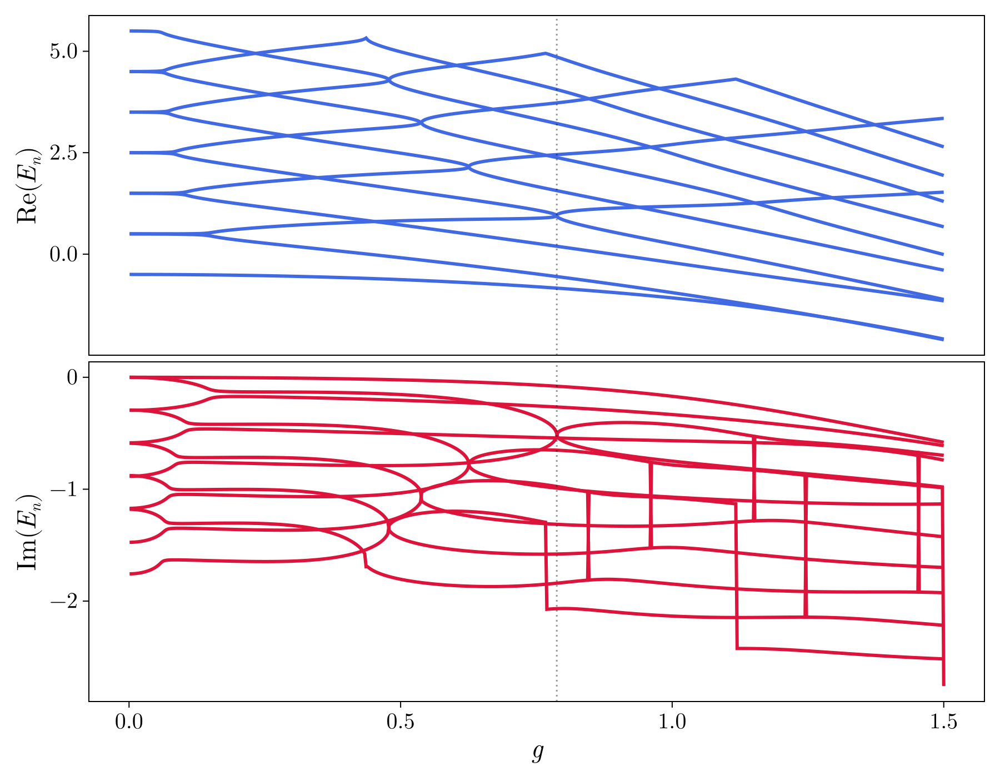

In [ ]:
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end

fig_cut = Figure(size = (900, 700))
a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n)")
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
hidexdecorations!(a1; grid = false)
a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end


ep  = eps_found[12]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end

linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)

rowgap!(fig_cut.layout, 6)
# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

## Study of the impact of $\gamma_b$

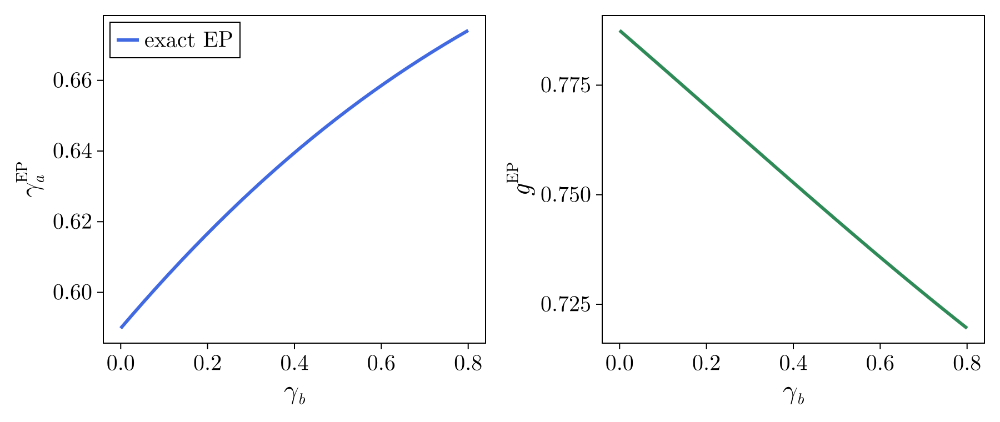

In [ ]:
ep = eps_found[12]
pa, pb = closest_pair(withp(P_NH; g = ep.g, γa = ep.γa), ep.parity)

γb_scan = range(0.0, 0.8, 30) |> collect
gEP  = similar(γb_scan)
γaEP = similar(γb_scan)

p = withp(P_NH; g = ep.g, γa = ep.γa)
for (i, γb) in enumerate(γb_scan)
    p = newton_ep(withp(p; γb = γb), :g, :γa, ep.parity, pa, pb)
    gEP[i] = p.g; γaEP[i] = p.γa
end

fig_γb = Figure(size = (900, 380))
axa = Axis(fig_γb[1, 1]; xlabel = L"\gamma_b", ylabel = L"\gamma_a^{\mathrm{EP}}")
lines!(axa, γb_scan, γaEP; color = :royalblue, label = "exact EP")
# lines!(axa, γb_scan, γaEP[1] .+ γb_scan; color = :crimson, linestyle = :dash, label = L"\gamma_a-\gamma_b=\mathrm{cost}\ (JC)")
axislegend(axa; position = :lt)
axg = Axis(fig_γb[1, 2]; xlabel = L"\gamma_b", ylabel = L"g^{\mathrm{EP}}")
lines!(axg, γb_scan, gEP; color = :seagreen)
save("ep_vs_gammab.png", fig_γb; px_per_unit = 3)
fig_γb

g = 0.7 : exact EPs on the (γa, γb) plane = 1
  γa = 0.4142   γb = 0.0592   odd   gap = 1.1e-7


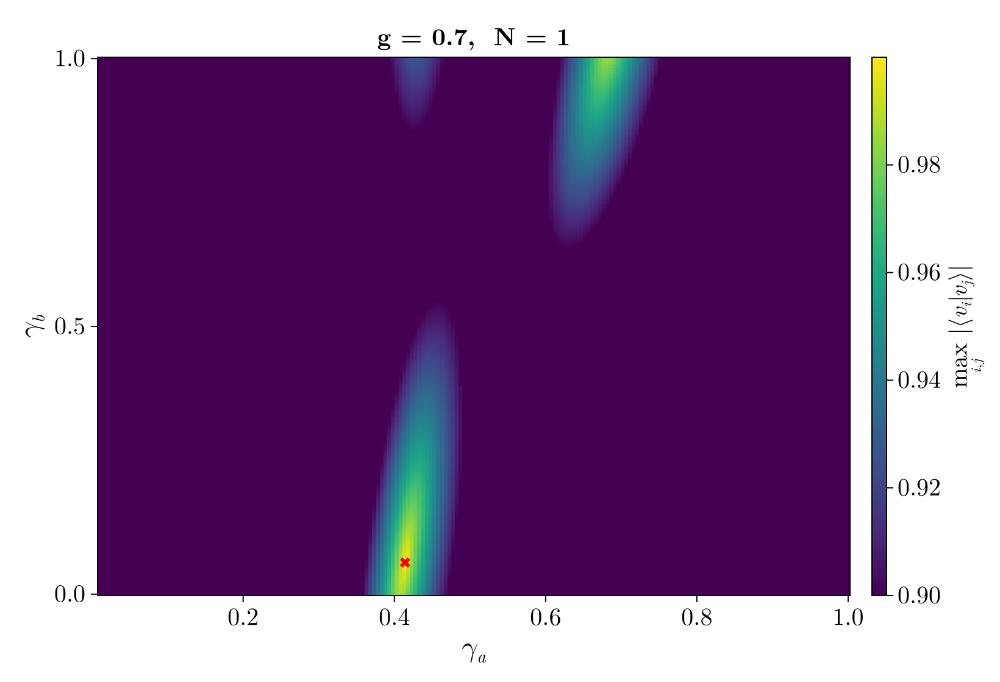

In [59]:
# Map exact EPs on the (γa, γb) plane at fixed g, tuning (:γa, :γb)
g_fix    = 0.7
γa_scan  = range(0.01, 1.0, 200) |> collect
γb_scan2 = range(0.0, 1.0, 200) |> collect

GAP2 = fill(Inf, length(γa_scan), length(γb_scan2))
OVL2 = zeros(length(γa_scan), length(γb_scan2))
PAR2 = fill(:even, length(γa_scan), length(γb_scan2))

for (i, γa) in enumerate(γa_scan), (j, γb) in enumerate(γb_scan2)
    He, Ho = parity_blocks_NH_coll(g_fix, _vars(withp(P_NH; g = g_fix, γa = γa, γb = γb)))
    me, oe = pair_gap_overlap(He)
    mo, oo = pair_gap_overlap(Ho)
    if me <= mo
        GAP2[i, j] = me
        OVL2[i, j] = oe
        PAR2[i, j] = :even
    else
        GAP2[i, j] = mo
        OVL2[i, j] = oo
        PAR2[i, j] = :odd
    end
end

eps_gab = NamedTuple[]
for i in 2:length(γa_scan)-1, j in 2:length(γb_scan2)-1
    if all(GAP2[i, j] <= GAP2[i+di, j+dj] for di in -1:1, dj in -1:1)   # 2D local minimum
        wh = PAR2[i, j]
        pseed = withp(P_NH; g = g_fix, γa = γa_scan[i], γb = γb_scan2[j])
        pa, pb = closest_pair(pseed, wh)
        pe = newton_ep(pseed, :γa, :γb, wh, pa, pb)
        gap, ov = ep_check(pe, wh, pa, pb)
        if gap < 1e-5 && ov > 1 - 1e-6 && pe.γa ≥ 0 && pe.γb ≥ 0
            e = (γa = round(pe.γa, digits = 4), γb = round(pe.γb, digits = 4), parity = wh, gap = gap, ov = ov)
            any(u -> abs(u.γa - e.γa) < 1e-2 && abs(u.γb - e.γb) < 1e-2, eps_gab) || push!(eps_gab, e)
        end
    end
end

println("g = $g_fix : exact EPs on the (γa, γb) plane = ", length(eps_gab))
foreach(e -> println("  γa = ", e.γa, "   γb = ", e.γb, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2)), eps_gab)

fig_gab = Figure(size = (820, 560))
axm = Axis(fig_gab[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "g = $g_fix,  N = $(P_NH.N)")
hmg = heatmap!(axm, γa_scan, γb_scan2, OVL2; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_gab[1, 2], hmg; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(axm, [e.γa for e in eps_gab], [e.γb for e in eps_gab]; color = :red, marker = :xcross, markersize = 12)
save("ep_map_gammas.png", fig_gab; px_per_unit = 3)
fig_gab

# Liouvillian case

## Emission spectrum

We use the emission spectrum to valide the energy levels and the system-bath coupling operators. The GME is used as with high filters to include the non-secular contributions. Low filters make the GME a dressed GKSL master equation, valid for weak system-bath couplings. For low intra-system couplings, it reduces to the standard Lindblad master equation.

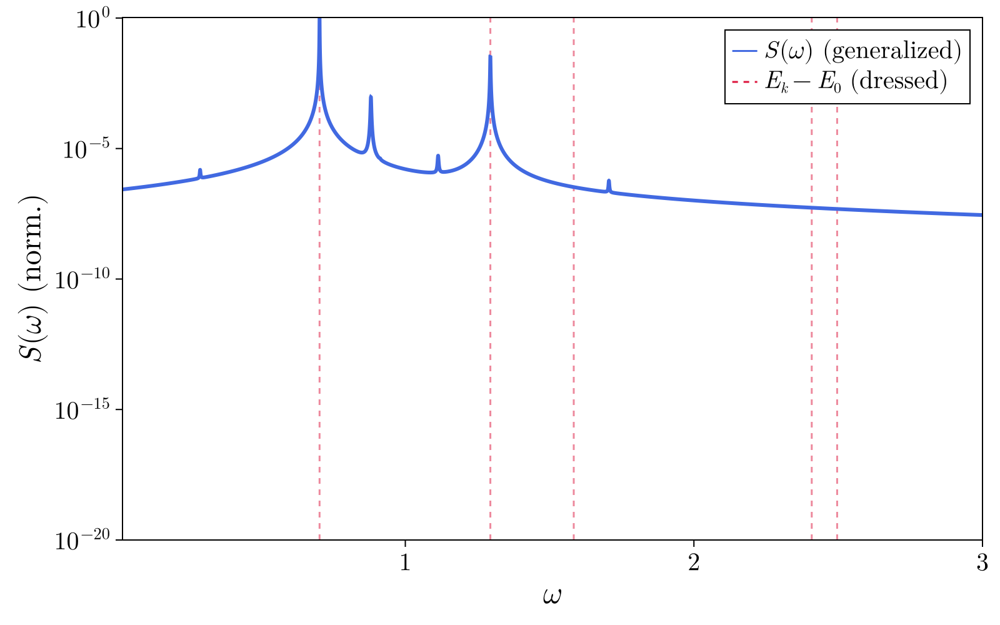

In [ ]:
vars_em = (ωa = 1.0, ωb = 1.0, Nc = 80, N = 1)
g_em, γ_em, T_em, NT_em = 0.3, 0.001, 0.15, 10

E_em, U_em, L_em = gen_liouvillian_qrm(g_em, vars_em, γ_em, T = [0.0, T_em], N_trunc = NT_em, σ_filter=0.1, tol=1e-12)

Ed = U_em.data' * qrm_emission_field(g_em, vars_em).data * U_em.data
Eplus = Qobj(triu(Ed, 1), dims=(NT_em,))

ω_em = range(0.02, 3.0, 50000) |> collect
S_em = spectrum(L_em, ω_em, nothing, Eplus', Eplus)
S_em ./= maximum(S_em)
S_plot = map(x -> x > 0 ? x : NaN, S_em)  

fig_em = Figure()
ax = Axis(fig_em[1, 1]; xlabel = L"\omega", ylabel = L"S(\omega)\ \mathrm{(norm.)}", limits = ((ω_em[1], ω_em[end]), (1e-20, 1.05)), yscale = log10)
for k in 2:min(8, length(E_em))
    vlines!(ax, [real(E_em[k] - E_em[1])]; color = (:crimson, 0.5), linestyle = :dash)
end
lines!(ax, ω_em, S_plot; color = :royalblue)

Legend(fig_em[1, 1], [LineElement(color = :royalblue), LineElement(color = :crimson, linestyle = :dash)], [L"S(\omega)\ \mathrm{(generalized)}", L"E_k - E_0\ \mathrm{(dressed)}"];
    tellwidth = false, tellheight = false, halign = :right, valign = :top, margin = (10, 10, 10, 10))

# save("emission_spectrum.png", fig_em; px_per_unit = 3)
fig_em

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


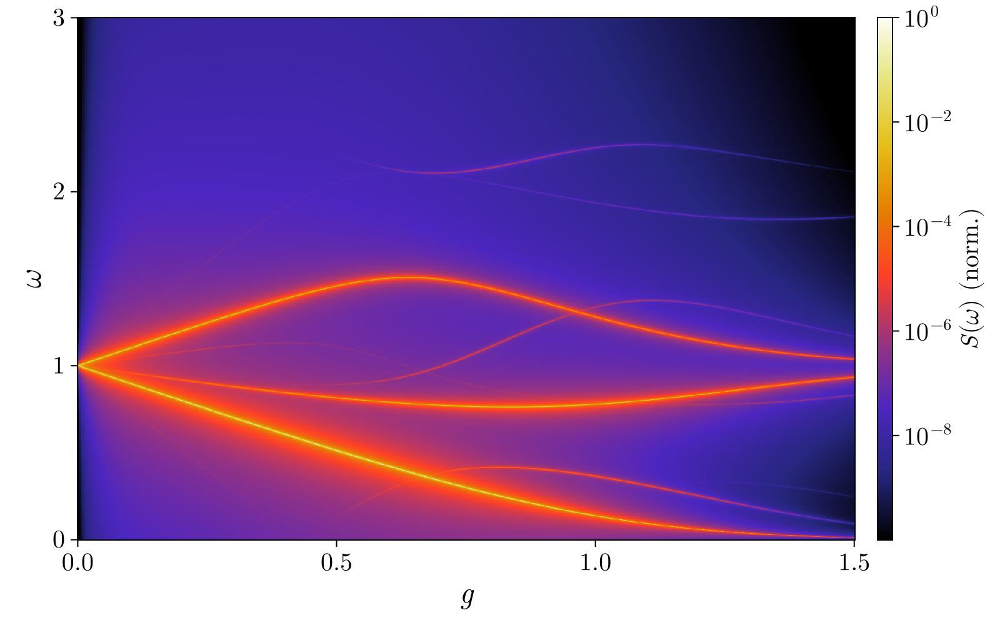

In [109]:
vars_em = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γ_em, T_em, NT_em = 0.001, 0.15, 10

g_list_em = range(1e-3, 1.5, 500) |> collect
ω_em = range(1e-5, 3.0, 1000) |> collect

S_map = zeros(length(ω_em), length(g_list_em))

Prog = Progress(length(g_list_em))
Threads.@threads for j in eachindex(g_list_em)
    g_em = g_list_em[j]
    E_em, U_em, L_em = gen_liouvillian_qrm(g_em, vars_em, γ_em; T = [0.0, T_em], N_trunc = NT_em, σ_filter = 0.1, tol = 1e-20)

    Ed = U_em.data' * qrm_emission_field(g_em, vars_em).data * U_em.data
    Eplus = Qobj(triu(Ed, 1), dims=(NT_em,))

    S_em = real.(spectrum(L_em, ω_em, nothing, Eplus', Eplus, solver=ExponentialSeries(tol=1e-20, calc_steadystate=true)))
    # S_em ./= maximum(S_em)
    S_map[:, j] .= S_em

    next!(Prog)
end

S_map ./= maximum(S_map)
S_map_log = map(x -> x > 0 ? x : NaN, S_map)  

fig_em_map = Figure()
ax = Axis(fig_em_map[1, 1]; xlabel = L"g", ylabel = L"\omega")
hm = heatmap!(ax, g_list_em, ω_em, S_map_log'; colormap = :CMRmap, colorscale = log10, colorrange = (1e-10, 1.0))
Colorbar(fig_em_map[1, 2], hm; label = L"S(\omega)\ \mathrm{(norm.)}")

# save("Julia/NHQRM/emission_spectrum_map.png", fig_em_map; px_per_unit = 3)
fig_em_map

## LEP

In [ ]:
function max_eigmat_overlap(g, γa, γb; σ_filter = 0.1, tol = 1e-20)
    _, _, L = gen_liouvillian_qrm(g, vars_map, [γa, γb], N_trunc = NT_map, σ_filter = σ_filter, tol = tol)
    F = eigen(Matrix(L.data))
    V = F.vectors
    for j in axes(V, 2) 
        V[:, j] ./= norm(V[:, j])
    end
    G = abs.(V' * V)

    s = argmin(abs.(F.values))
    n = length(F.values)
    G[s, :] .= 0
    G[:, s] .= 0
    for i in 1:n
        G[i, i] = 0
    end   # exclude steady state and diagonal
    
    return maximum(G)
end

function max_eigmat_ep(g, γa, γb; σ_filter = 0.1, tol = 1e-20, tol_val=1e-4)
    _, _, L = gen_liouvillian_qrm(g, vars_map, [γa, γb], N_trunc = NT_map, σ_filter = σ_filter, tol = tol)
    F = eigen(Matrix(L.data))
    vecs = F.vectors
    for j in axes(vecs, 2) 
        vecs[:, j] ./= norm(vecs[:, j])
    end
    G = abs.(vecs' * vecs)
    
    s = argmin(abs.(F.values))
    n = length(F.values)
    G[s, :] .= 0
    G[:, s] .= 0
    for i in 1:n
        G[i, i] = 0
    end   # exclude steady state and diagonal

    ep_check = true ? abs(F.values[argmax(G)[1]]-F.values[argmax(G)[2]])<tol_val : false

    return maximum(G), ep_check, F.values[argmax(G)[1]], F.values[argmax(G)[2]]
end

max_eigmat_ep (generic function with 1 method)

### Scanning $g$ and $\gamma_a$

Progress: 100%|█████████████████████████████████████████| Time: 0:02:17


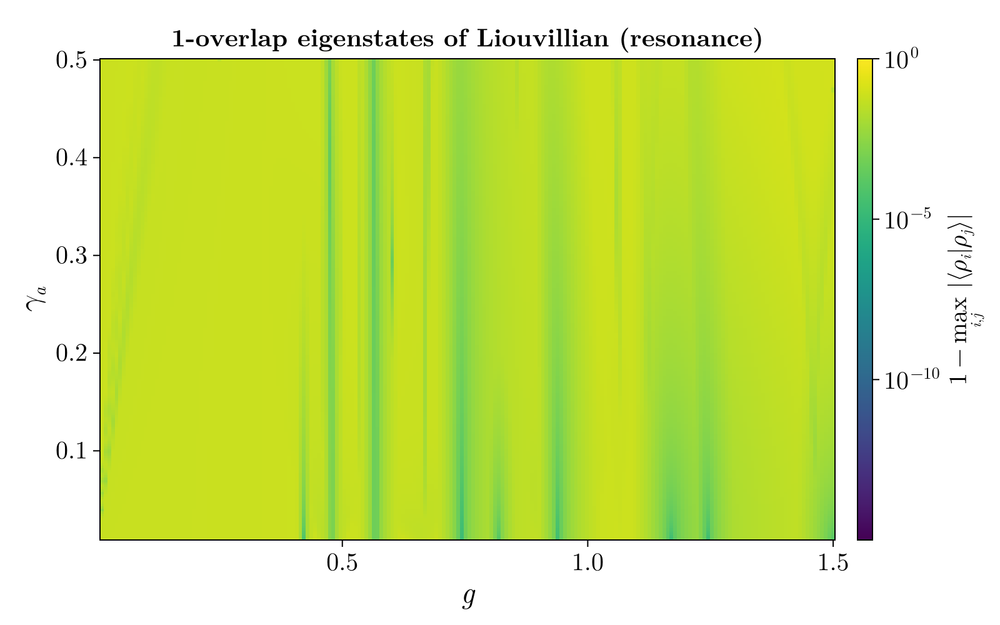

In [ ]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_map  = range(0.01, 1.5, 200) |> collect
γa_map  = range(0.001, 0.1, 200) |> collect
NT_map = 10

OVL_map_non_sec = fill(0.0, length(g_map), length(γa_map))

Prog = Progress(length(g_map))
Threads.@threads for i in eachindex(g_map)
    for j in eachindex(γa_map)
        OVL_map_non_sec[i, j] = 1.0 - max_eigmat_overlap(g_map[i], γa_map[j], 0.0; σ_filter = 10, tol = 1e-20)
    end
    next!(Prog)
end

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "1-overlap eigenstates of Liouvillian (resonance)")
hm = heatmap!(ax, g_map, γa_map, OVL_map_non_sec; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("usc_overlap_map.png", fig_ovl; px_per_unit = 3)
fig_ovl

Progress: 100%|█████████████████████████████████████████| Time: 0:02:07


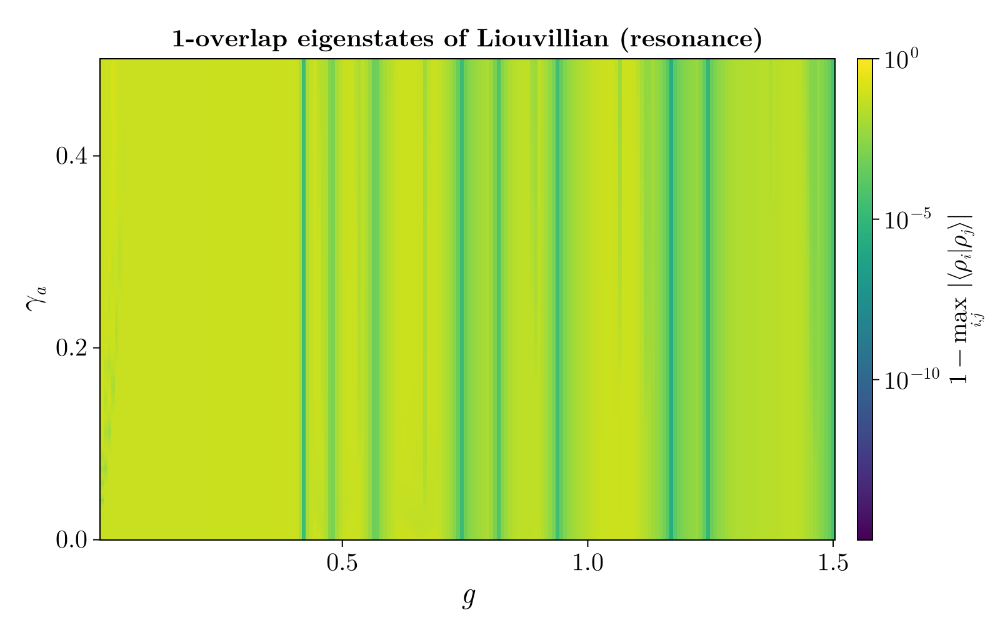

In [ ]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_map  = range(0.01, 1.5, 200) |> collect
γa_map  = range(0.001, 0.1, 200) |> collect
NT_map = 10

OVL_map_sec = fill(0.0, length(g_map), length(γa_map))

Prog = Progress(length(g_map))
Threads.@threads for i in eachindex(g_map)
    for j in eachindex(γa_map)
        OVL_map_sec[i, j] = 1.0 - max_eigmat_overlap(g_map[i], γa_map[j], 0.0; σ_filter = 0.1, tol = 1e-20)
    end
    next!(Prog)
end

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "1-overlap eigenstates of Liouvillian (resonance)")
hm = heatmap!(ax, g_map, γa_map, OVL_map_sec; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("usc_overlap_map.png", fig_ovl; px_per_unit = 3)
fig_ovl

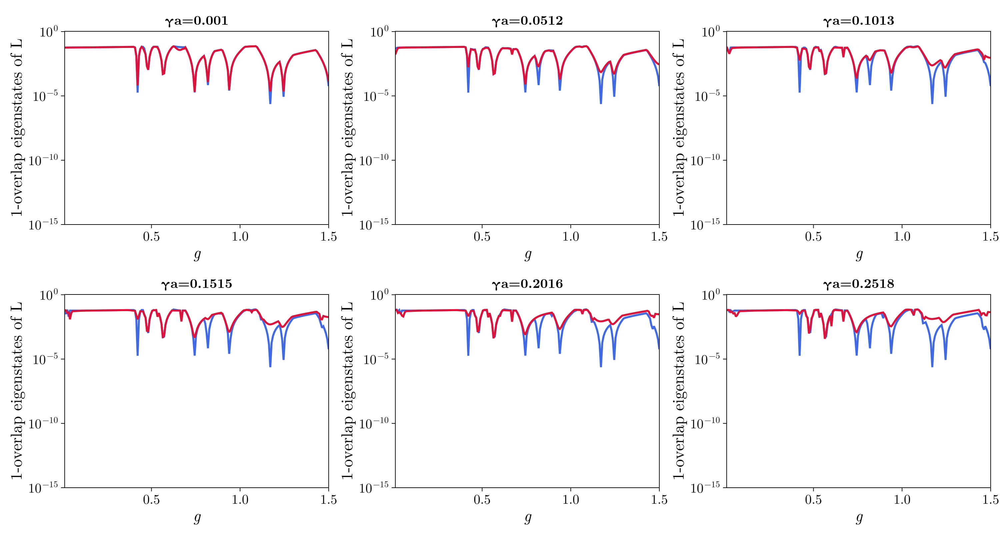

In [132]:
step_ind = 20
inds = 1:step_ind:(5*step_ind+1)

fig_comp = Figure(size = (1500, 800))
for (subplot, ind) in enumerate(inds)
    row = cld(subplot, 3)
    col = mod1(subplot, 3)
    ax = Axis(fig_comp[row, col]; xlabel = L"g", ylabel = "1-overlap eigenstates of L", title = "γa=$(round(γa_map[ind], digits=4))", limits = ((g_map[1], g_map[end]), (1e-15, 1.05)), yscale = log10)
    lines!(ax, g_map, OVL_map_sec[:, ind]; color = :royalblue)
    lines!(ax, g_map, OVL_map_non_sec[:, ind]; color = :crimson)
end

# save("usc_overlap_map.png", fig_comp; px_per_unit = 3)
fig_comp

### Scanning $\gamma_a$ and $\gamma_b$ in USC

Progress: 100%|█████████████████████████████████████████| Time: 0:13:10


min overlap = 0.9338247960382745 at (γa, γb) = (0.199, 0.332)
max overlap (1-overlap) = 1.4954704141700859e-13 at (γa, γb) = (0.011, 0.246)


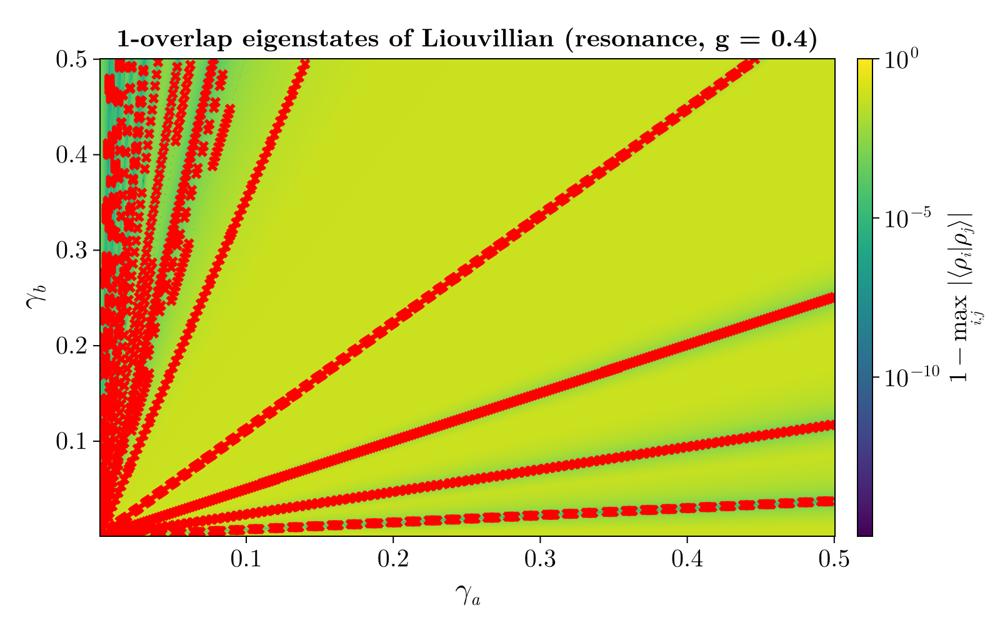

In [144]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γa_map  = range(0.001, 0.5, 500) |> collect
γb_map  = range(0.001, 0.5, 500) |> collect
g_map = 0.4
NT_map = 10

OVL_map = fill(0.0, length(γa_map), length(γb_map))
OVL_map_check = fill(false, length(γa_map), length(γb_map))
eigvals_ep = Tuple{ComplexF64, ComplexF64, Float64, Float64}[]

Prog = Progress(length(γa_map))
Threads.@threads for i in eachindex(γa_map)
    for j in eachindex(γb_map)
        vv = max_eigmat_ep(g_map, γa_map[i], γb_map[j], tol_val=1e-4, σ_filter = 0.1, tol = 1e-20)
        OVL_map[i, j] = 1.0 - vv[1]
        OVL_map_check[i, j] = vv[2]
        if vv[2]
            push!(eigvals_ep, (vv[3], vv[4], γa_map[i], γb_map[j]))
        end
    end
    next!(Prog)
end
println("min overlap = ", 1.0-maximum(OVL_map), " at (γa, γb) = (", round(γa_map[argmax(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmax(OVL_map)[2]], digits = 4), ")")
println("max overlap (1-overlap) = ", minimum(OVL_map), " at (γa, γb) = (", round(γa_map[argmin(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmin(OVL_map)[2]], digits = 4), ")")

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "1-overlap eigenstates of Liouvillian (resonance, g = $g_map)")
hm = heatmap!(ax, γa_map, γb_map, OVL_map; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("Julia/NHQRM/USC_overlap_map_gamma_g04.pdf", fig_ovl; px_per_unit = 3)

for ind in findall(OVL_map_check)
    scatter!(ax, [γa_map[ind[1]]], [γb_map[ind[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("Julia/NHQRM/USC_overlap_map_gamma_g04_withEP.pdf", fig_ovl; px_per_unit = 3)
fig_ovl

Progress: 100%|█████████████████████████████████████████| Time: 0:14:26


min overlap = 0.933030178108252 at (γa, γb) = (0.071, 0.173)
max overlap (1-overlap) = 1.3402658982641924e-8 at (γa, γb) = (0.014, 0.221)


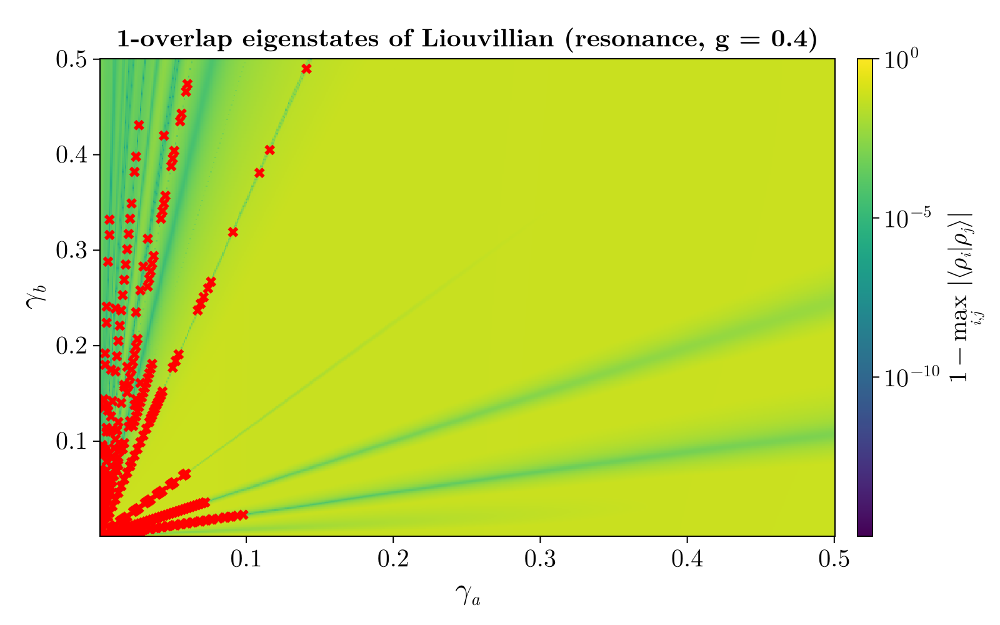

In [145]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γa_map  = range(0.001, 0.5, 500) |> collect
γb_map  = range(0.001, 0.5, 500) |> collect
g_map = 0.4
NT_map = 10

OVL_map = fill(0.0, length(γa_map), length(γb_map))
OVL_map_check = fill(false, length(γa_map), length(γb_map))
eigvals_ep = Tuple{ComplexF64, ComplexF64, Float64, Float64}[]

Prog = Progress(length(γa_map))
Threads.@threads for i in eachindex(γa_map)
    for j in eachindex(γb_map)
        vv = max_eigmat_ep(g_map, γa_map[i], γb_map[j], tol_val=1e-4, σ_filter = 10, tol = 1e-20)
        OVL_map[i, j] = 1.0 - vv[1]
        OVL_map_check[i, j] = vv[2]
        if vv[2]
            push!(eigvals_ep, (vv[3], vv[4], γa_map[i], γb_map[j]))
        end
    end
    next!(Prog)
end
println("min overlap = ", 1.0-maximum(OVL_map), " at (γa, γb) = (", round(γa_map[argmax(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmax(OVL_map)[2]], digits = 4), ")")
println("max overlap (1-overlap) = ", minimum(OVL_map), " at (γa, γb) = (", round(γa_map[argmin(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmin(OVL_map)[2]], digits = 4), ")")

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "1-overlap eigenstates of Liouvillian (resonance, g = $g_map)")
hm = heatmap!(ax, γa_map, γb_map, OVL_map; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("Julia/NHQRM/USC_overlap_map_gamma_g04.pdf", fig_ovl; px_per_unit = 3)

for ind in findall(OVL_map_check)
    scatter!(ax, [γa_map[ind[1]]], [γb_map[ind[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("Julia/NHQRM/USC_overlap_map_gamma_g04_withEP.pdf", fig_ovl; px_per_unit = 3)
fig_ovl

### Liouvillian eigenspectrum

In [189]:
eigvals_ep[161]

(-0.08085950020185659 + 3.0868732732802653e-15im, -0.08092927993726132 - 9.81390597779164e-16im, 0.021, 0.121)

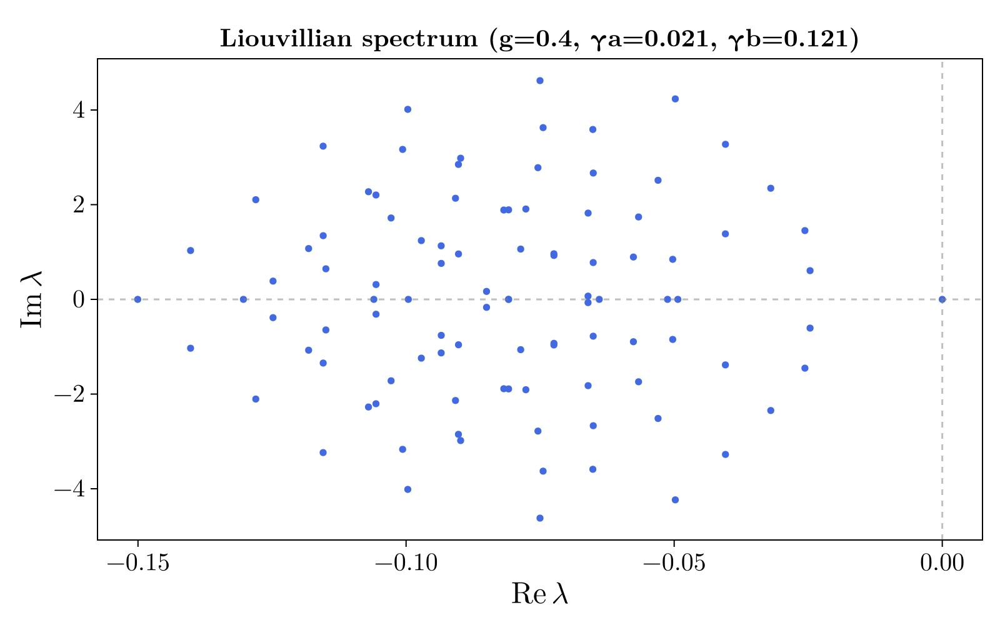

In [167]:
vars_sp = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_sp, NT_sp = 0.4, 10
_, _, L_sp = gen_liouvillian_qrm(g_sp, vars_sp, [eigvals_ep[161][3], eigvals_ep[161][4]], N_trunc = NT_sp, σ_filter = 0.1, tol = 1e-20)
λ_sp = eigvals(Matrix(L_sp.data))

fig_sp = Figure()
ax = Axis(fig_sp[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Liouvillian spectrum (g=$g_sp, γa=$(eigvals_ep[161][3]), γb=$(eigvals_ep[161][4]))")
scatter!(ax, real.(λ_sp), imag.(λ_sp); color = :royalblue, markersize = 8)

vlines!(ax, 0; color = (:grey, 0.5), linestyle = :dash)
hlines!(ax, 0; color = (:grey, 0.5), linestyle = :dash)

# save("liouvillian_spectrum.png", fig_sp; px_per_unit = 3)
fig_sp

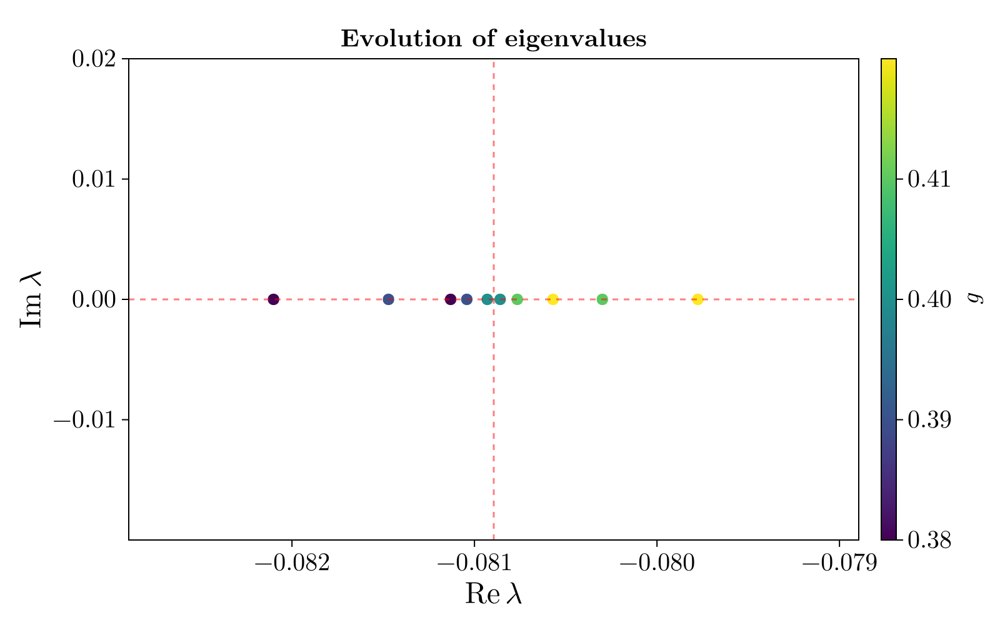

In [187]:
ind = 161
g_ev = range(0.38, 0.42, 5) |> collect
# g_ev = 0.3989

fig_ev = Figure()
ax = Axis(fig_ev[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Evolution of eigenvalues", limits = ((real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.002, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.002),(imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02)))
for g in g_ev
    _, _, L = gen_liouvillian_qrm(g, vars_map, [eigvals_ep[ind][3], eigvals_ep[ind][4]], N_trunc = 10, tol = 1e-20)
    λ = eigvals(Matrix(L.data))
    sel = filter(z -> abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) + 0.01 > abs(real(z)) > abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) - 0.01 && imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02 > abs(imag(z)) > imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, λ)
    scatter!(ax, real.(sel), imag.(sel); color = fill(g, length(sel)), colormap = :viridis, colorrange = (g_ev[1], g_ev[end]), markersize = 13)
end
Colorbar(fig_ev[1, 2]; limits = (g_ev[1], g_ev[end]), colormap = :viridis, label = L"g")

vlines!(ax, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("eigenvalue_evolution.png", fig_ev; px_per_unit = 3)
fig_ev

In [203]:
eigvals_ep[73]

(-0.015284412443409584 - 6.149103036916965e-14im, -0.015375510834346236 + 5.145210181473623e-14im, 0.002, 0.057)

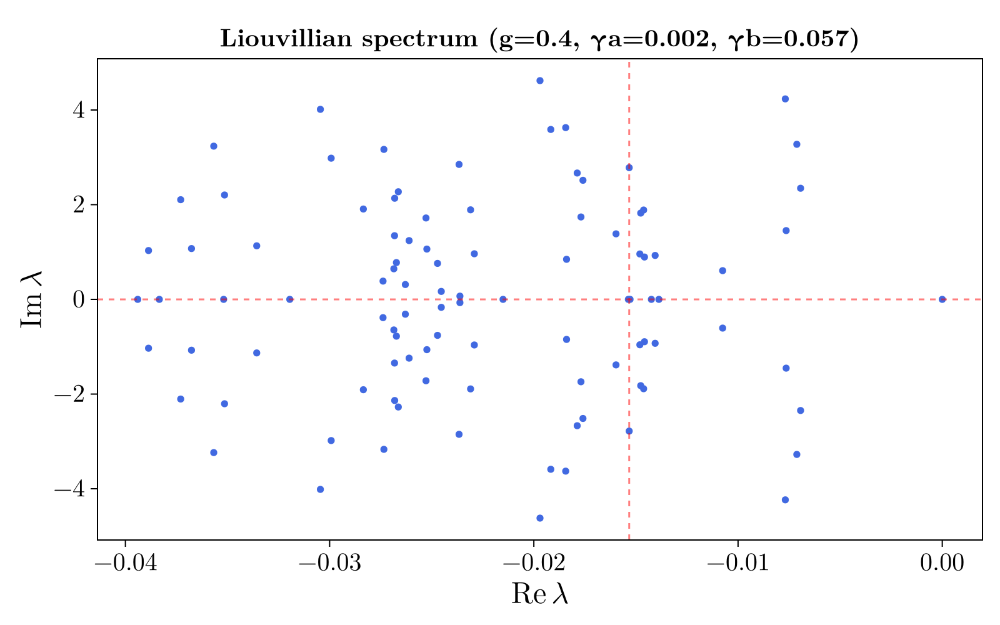

In [207]:
vars_sp = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_sp, NT_sp = 0.4, 10
_, _, L_sp = gen_liouvillian_qrm(g_sp, vars_sp, [eigvals_ep[73][3], eigvals_ep[73][4]], N_trunc = NT_sp, σ_filter = 0.1, tol = 1e-20)
λ_sp = eigvals(Matrix(L_sp.data))

fig_sp = Figure()
ax = Axis(fig_sp[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Liouvillian spectrum (g=$g_sp, γa=$(eigvals_ep[73][3]), γb=$(eigvals_ep[73][4]))")
scatter!(ax, real.(λ_sp), imag.(λ_sp); color = :royalblue, markersize = 8)

vlines!(ax, real(eigvals_ep[73][1]+eigvals_ep[73][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[73][1]+eigvals_ep[73][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("liouvillian_spectrum.png", fig_sp; px_per_unit = 3)
fig_sp

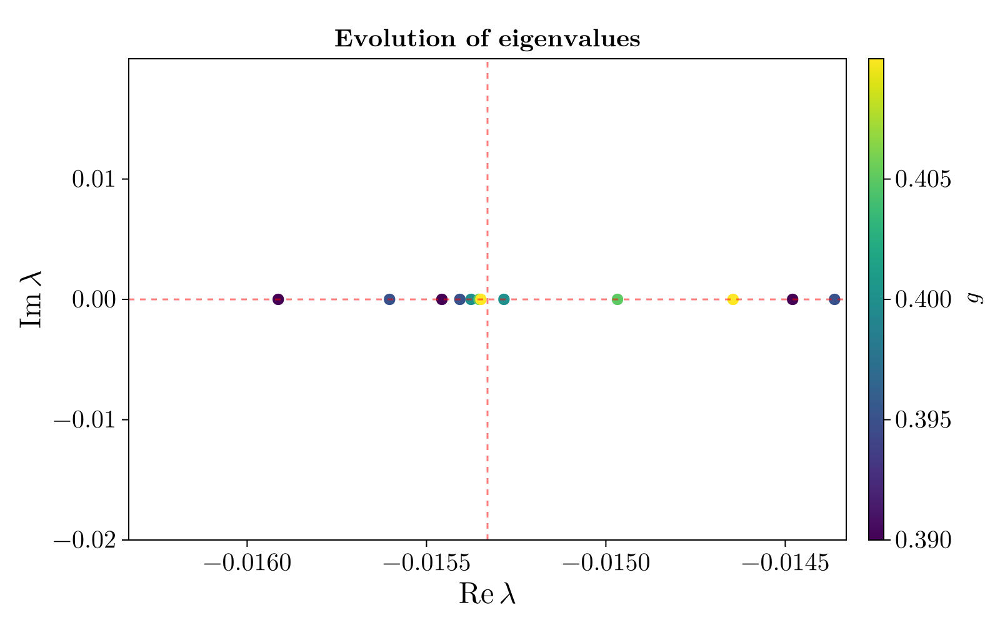

In [221]:
ind = 73
g_ev = range(0.39, 0.41, 5) |> collect
# g_ev = 0.4

fig_ev = Figure()
ax = Axis(fig_ev[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Evolution of eigenvalues", limits = ((real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.001, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.001),(imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02)))
for g in g_ev
    _, _, L = gen_liouvillian_qrm(g, vars_map, [eigvals_ep[ind][3], eigvals_ep[ind][4]], N_trunc = 10, tol = 1e-20)
    λ = eigvals(Matrix(L.data))
    sel = filter(z -> abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) + 0.002 > abs(real(z)) > abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) - 0.002 && imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02 > abs(imag(z)) > imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, λ)
    scatter!(ax, real.(sel), imag.(sel); color = fill(g, length(sel)), colormap = :viridis, colorrange = (g_ev[1], g_ev[end]), markersize = 13)
end
Colorbar(fig_ev[1, 2]; limits = (g_ev[1], g_ev[end]), colormap = :viridis, label = L"g")

vlines!(ax, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("eigenvalue_evolution.png", fig_ev; px_per_unit = 3)
fig_ev

In [4]:
function Lmat(g, ωb, γ; Nc, NT)
    v = (ωa = 1.0, ωb = ωb, Nc = Nc, N = 1)
    _, _, L = gen_liouvillian_qrm(g, v, γ; N_trunc = NT)
    return Matrix(L.data)
end

function is_ep(x0, y0, κ0; knob = :ωb, r = 0.01, nθ = 200, Nc = 20, NT = 6)
    Lf = knob === :ωb ? ((x, y) -> Lmat(x, y, κ0; Nc, NT)) : ((x, y) -> Lmat(x, 1.0, y; Nc, NT))
    c = eigvals(Lf(x0, y0)); n = length(c); dmin = Inf; λ0 = 0.0im
    for i in 1:n, j in i+1:n
        d = abs(c[i] - c[j]); d < dmin && (dmin = d; λ0 = (c[i] + c[j]) / 2)
    end
    v = eigvals(Lf(x0 + r, y0)); ord = sortperm(abs.(v .- λ0)); λ1, λ2 = v[ord[1]], v[ord[2]]
    λ1s, λ2s = λ1, λ2
    for k in 1:nθ
        θ = 2π * k / nθ; v = eigvals(Lf(x0 + r*cos(θ), y0 + r*sin(θ)))
        mid = (λ1 + λ2) / 2; ord = sortperm(abs.(v .- mid)); a1, a2 = v[ord[1]], v[ord[2]]
        if abs(a1-λ1)+abs(a2-λ2) <= abs(a1-λ2)+abs(a2-λ1); λ1, λ2 = a1, a2; else; λ1, λ2 = a2, a1; end
    end
    swapped = abs(λ1-λ2s)+abs(λ2-λ1s) < abs(λ1-λ1s)+abs(λ2-λ2s)
    return swapped, dmin
end

is_ep (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:31:15


Candidati:   g       γa      gap          loc
           0.817   0.001   1.89e-9      -0.00394 + 0.0im
           0.817   0.001   2.07e-9      -0.00433 + 0.0im
           0.817   0.001   2.26e-9      -0.00472 + 0.0im
           0.817   0.001   2.45e-9      -0.00511 + 0.0im
           0.817   0.001   2.63e-9      -0.00551 + 0.0im
           0.817   0.001   2.82e-9      -0.0059 + 0.0im
           0.817   0.002   3.01e-9      -0.00629 + 0.0im
           0.817   0.002   3.2e-9       -0.00668 + 0.0im


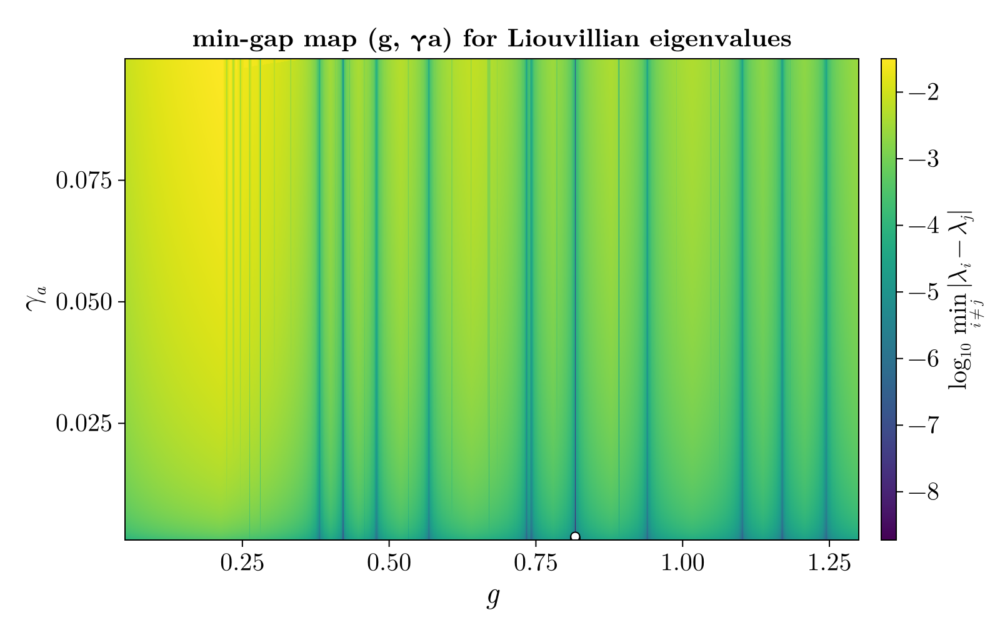

In [ ]:
vars_ep     = (ωa = 1.0, ωb = 1.0, Nc = 80, N = 1)
NT_ep, σ_ep = 12, 0.1                    # dressed truncation, non-secular filter ≈ γ
win_ep      = (-0.5, -1e-4, -1.5, 1.5)    # slow modes; excludes the steady state at 0

g_grid = range(0.05, 1.3, 1000) |> collect
γa_grid = range(0.001, 0.1, 1000) |> collect

gapmap = fill(NaN, length(γa_grid), length(g_grid))
locmap = fill(NaN + 0im, length(γa_grid), length(g_grid))

Prog = Progress(length(g_grid))
Threads.@threads for ig in eachindex(g_grid)
    for ik in eachindex(γa_grid)
        _, _, L = gen_liouvillian_qrm(g_grid[ig], vars_ep, [γa_grid[ik], 0.0];
                                    N_trunc = NT_ep, σ_filter = σ_ep)
        r = lep_min_gap(L; window = win_ep, exclude_zero = true)
        gapmap[ik, ig] = r.gap
        locmap[ik, ig] = r.loc
    end
    next!(Prog)
end

# Candidates: points with the smallest gap (tracing the quasi-degeneracy locus)
cand = sort(vec([(gapmap[ik, ig], ig, ik) for ik in eachindex(γa_grid), ig in eachindex(g_grid)]);
            by = first)
println("Candidates:   g       γa      gap          loc")
for t in 1:8
    gp, ig, ik = cand[t]
    println("           ", rpad(round(g_grid[ig], digits = 3), 8), rpad(round(γa_grid[ik], digits = 3), 8),
            rpad(round(gp, sigdigits = 3), 13), round(locmap[ik, ig], sigdigits = 3))
end

fig_ep = Figure()
ax = Axis(fig_ep[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "min-gap map (g, γa) for Liouvillian eigenvalues",
          limits = ((g_grid[1], g_grid[end]), (γa_grid[1], γa_grid[end])))
hm = heatmap!(ax, g_grid, γa_grid, permutedims(log10.(gapmap)); colormap = :viridis)
Colorbar(fig_ep[1, 2], hm; label = L"\log_{10}\,\min_{i\neq j}|\lambda_i-\lambda_j|")
scatter!(ax, [g_grid[cand[t][2]] for t in 1:8], [γa_grid[cand[t][3]] for t in 1:8];
         color = :white, markersize = 10, strokecolor = :black, strokewidth = 1)

# save("lep_mingap_scan.png", fig_ep; px_per_unit = 3)
fig_ep

In [6]:
NT_ep, σ_ep, Nc_ep = 6, 0.1, 30
win_ep = (-0.5, -1e-4, -1.5, 1.5)

g_grid  = range(0.01, 1.2, 120) |> collect
ωb_grid = range(0.9, 1.1, 81) |> collect
γa_grid = range(1e-4, 0.05, 400) |> collect
γb_grid = range(1e-4, 0.05, 400) |> collect

gapmap = fill(NaN, length(ωb_grid), length(g_grid))
γa_map = fill(NaN, length(ωb_grid), length(g_grid))
γb_map = fill(NaN, length(ωb_grid), length(g_grid))

Prog = Progress(length(g_grid)*length(ωb_grid))
lk = ReentrantLock()
Threads.@threads for ig in eachindex(g_grid)
    for iw in eachindex(ωb_grid)
        vloc = (ωa = 1.0, ωb = ωb_grid[iw], Nc = Nc_ep, N = 1)
        bg = Inf; ba = NaN; bb = NaN
        for a in γa_grid, b in γb_grid
            (a == 0 && b == 0) && continue
            L = gen_liouvillian_qrm(g_grid[ig], vloc, [a, b]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
            gp = lep_min_gap(L; window = win_ep, exclude_zero = true).gap
            gp < bg && (bg = gp; ba = a; bb = b)
        end
        gapmap[iw, ig] = bg
        γa_map[iw, ig] = ba
        γb_map[iw, ig] = bb
        lock(lk) do; next!(Prog) end
    end
end

interior(a, b) = (γa_grid[1] < a < γa_grid[end]) && (γb_grid[1] < b < γb_grid[end])
allc = sort(vec([(gapmap[iw, ig], ig, iw) for iw in eachindex(ωb_grid), ig in eachindex(g_grid)]); by = first)
println("EP Candidates (γ* inside):   g       ωb      gap          γa*     γb*")
shown = 0
for (gp, ig, iw) in allc
    interior(γa_map[iw, ig], γb_map[iw, ig]) || continue
    println("                           ", rpad(round(g_grid[ig], digits=3), 8), rpad(round(ωb_grid[iw], digits=3), 8),
            rpad(round(gp, sigdigits=3), 13), rpad(round(γa_map[iw, ig], digits=4), 8), round(γb_map[iw, ig], digits=4))
    (shown += 1) ≥ 5 && break
end
shown == 0 && println("  (no candidate to γ* inside the region: al the minima are on the edges of the γa, γb grid)")

fig_4d = Figure(size = (1500, 430))
for (col, M, ttl, cmap, logk) in ((1, gapmap, L"\log_{10}\,\mathrm{gap}_{\min}", :viridis, true),
                                  (3, γa_map, L"\gamma_a^\star", :magma, false),
                                  (5, γb_map, L"\gamma_b^\star", :magma, false))
    ax = Axis(fig_4d[1, col]; xlabel = L"g", ylabel = L"\omega_b", title = ttl, limits = ((g_grid[1], g_grid[end]), (ωb_grid[1], ωb_grid[end])))
    hm = heatmap!(ax, g_grid, ωb_grid, permutedims(logk ? log10.(M) : M); colormap = cmap)
    Colorbar(fig_4d[1, col+1], hm)
end

# save("lep_4param_scan.png", fig_4d; px_per_unit = 3)
fig_4d

Progress:   1%|▎                                        |  ETA: 4 days, 3:03:29m

LoadError: InterruptException:

Progress: 100%|█████████████████████████████████████████| Time: 0:06:01


Glbal minima:   g       γa      γb      gap          γ* inside?
  0.52    0.0001  0.0121  7.51e-10     edge (trivial/DP)
  0.19    0.0001  0.0259  8.04e-9      edge (trivial/DP)
  0.55    0.0462  0.019   1.12e-8      yes (EP candidate)
  0.24    0.0001  0.0139  5.41e-8      edge (trivial/DP)
  0.02    0.0001  0.0156  8.31e-8      edge (trivial/DP)
  0.83    0.0052  0.0139  1.06e-7      yes (EP candidate)
  0.23    0.0244  0.0397  1.13e-7      yes (EP candidate)
  0.12    0.0039  0.0483  1.15e-7      yes (EP candidate)


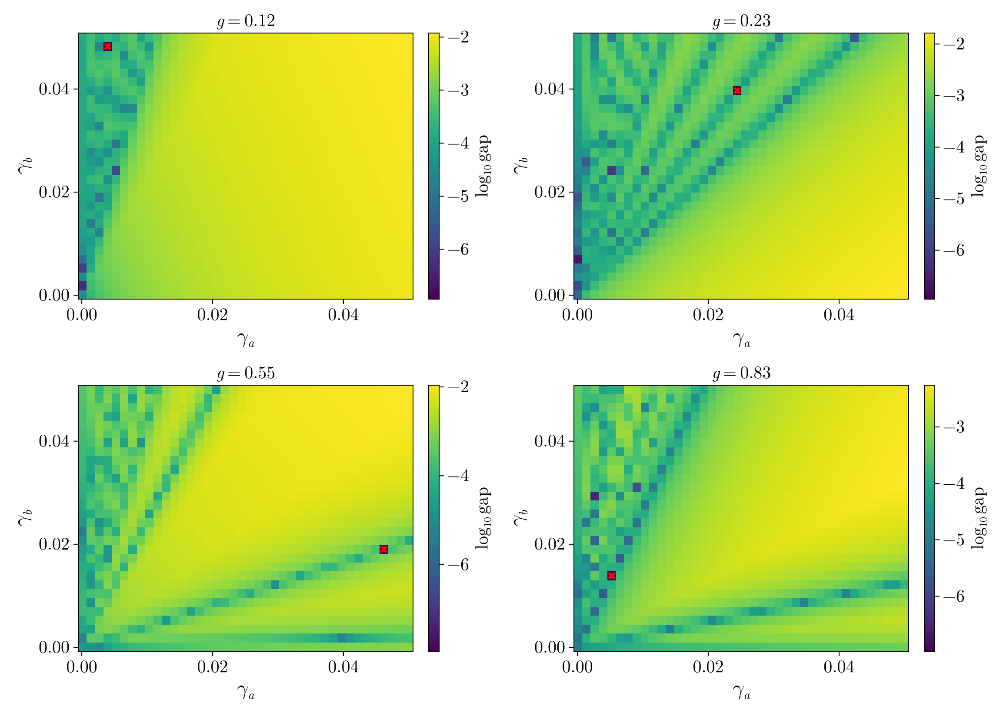

In [ ]:
NT_ep, σ_ep, Nc_ep = 10, 0.1, 100
win_ep = (-0.5, -1e-4, -1.5, 1.5)
vars_r = (ωa = 1.0, ωb = 1.0, Nc = Nc_ep, N = 1)

g_grid  = range(0.01, 1.2, 120) |> collect
γa_grid = range(1e-4, 0.05, 40) |> collect
γb_grid = range(1e-4, 0.05, 30) |> collect
gap3 = fill(NaN, length(g_grid), length(γa_grid), length(γb_grid))

Prog = Progress(length(g_grid))
Threads.@threads for ig in eachindex(g_grid)
    for ia in eachindex(γa_grid), ib in eachindex(γb_grid)
        (γa_grid[ia] == 0 && γb_grid[ib] == 0) && continue
        L = gen_liouvillian_qrm(g_grid[ig], vars_r, [γa_grid[ia], γb_grid[ib]]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
        gap3[ig, ia, ib] = lep_min_gap(L; window = win_ep, exclude_zero = true).gap
    end
    next!(Prog)
end

interior(a, b) = (γa_grid[1] < a < γa_grid[end]) && (γb_grid[1] < b < γb_grid[end])
allc = sort([(gap3[ig,ia,ib], ig, ia, ib) for ig in eachindex(g_grid), ia in eachindex(γa_grid),
             ib in eachindex(γb_grid) if !isnan(gap3[ig,ia,ib])] |> vec; by = first)
println("Glbal minima:   g       γa      γb      gap          γ* inside?")
for (gp, ig, ia, ib) in allc[1:min(8, length(allc))]
    println("  ", rpad(round(g_grid[ig],digits=3),8), rpad(round(γa_grid[ia],digits=4),8),
            rpad(round(γb_grid[ib],digits=4),8), rpad(round(gp,sigdigits=3),13),
            interior(γa_grid[ia], γb_grid[ib]) ? "yes (EP candidate)" : "edge (trivial/DP)")
end

g_slices = nothing        # ex. [0.4, 0.73, 1.0, 1.25] otherwise
if g_slices === nothing
    cand_gidx = unique([c[2] for c in allc if interior(γa_grid[c[3]], γb_grid[c[4]])])
    sidx = Int[]
    for gi in cand_gidx; length(sidx) ≥ 4 && break; push!(sidx, gi); end
    for gi in round.(Int, range(1, length(g_grid), 4))
        length(sidx) ≥ 4 && break; (gi in sidx) || push!(sidx, gi)
    end
    sort!(sidx)
else
    sidx = sort(unique([argmin(abs.(g_grid .- gs)) for gs in g_slices]))
end


fig_3d = Figure(size = (1150, 820))
for (p, ig) in enumerate(sidx)
    r = (p - 1) ÷ 2 + 1; c0 = ((p - 1) % 2) * 2
    S  = gap3[ig, :, :]
    ax = Axis(fig_3d[r, c0+1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b",
              title = L"g = %$(round(g_grid[ig], digits=3))")
    hm = heatmap!(ax, γa_grid, γb_grid, log10.(S); colormap = :viridis)
    Colorbar(fig_3d[r, c0+2], hm; label = L"\log_{10}\mathrm{gap}")
    jm = argmin([isnan(S[i,j]) ? Inf : S[i,j] for i in axes(S,1), j in axes(S,2)])
    scatter!(ax, [γa_grid[jm[1]]], [γb_grid[jm[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("lep_bruteforce_slices.png", fig_3d; px_per_unit = 3)
fig_3d

Progress: 100%|█████████████████████████████████████████| Time: 0:01:11


Glbal minima:   g       γa      γb      gap          γ* inside?
  0.52    0.0001  0.0121  7.51e-10     edge (trivial/DP)
  0.19    0.0001  0.0259  8.04e-9      edge (trivial/DP)
  0.55    0.0462  0.019   1.12e-8      yes (EP candidate)
  0.24    0.0001  0.0139  5.41e-8      edge (trivial/DP)
  0.02    0.0001  0.0156  8.31e-8      edge (trivial/DP)
  0.83    0.0052  0.0139  1.06e-7      yes (EP candidate)
  0.23    0.0244  0.0397  1.13e-7      yes (EP candidate)
  0.12    0.0039  0.0483  1.15e-7      yes (EP candidate)


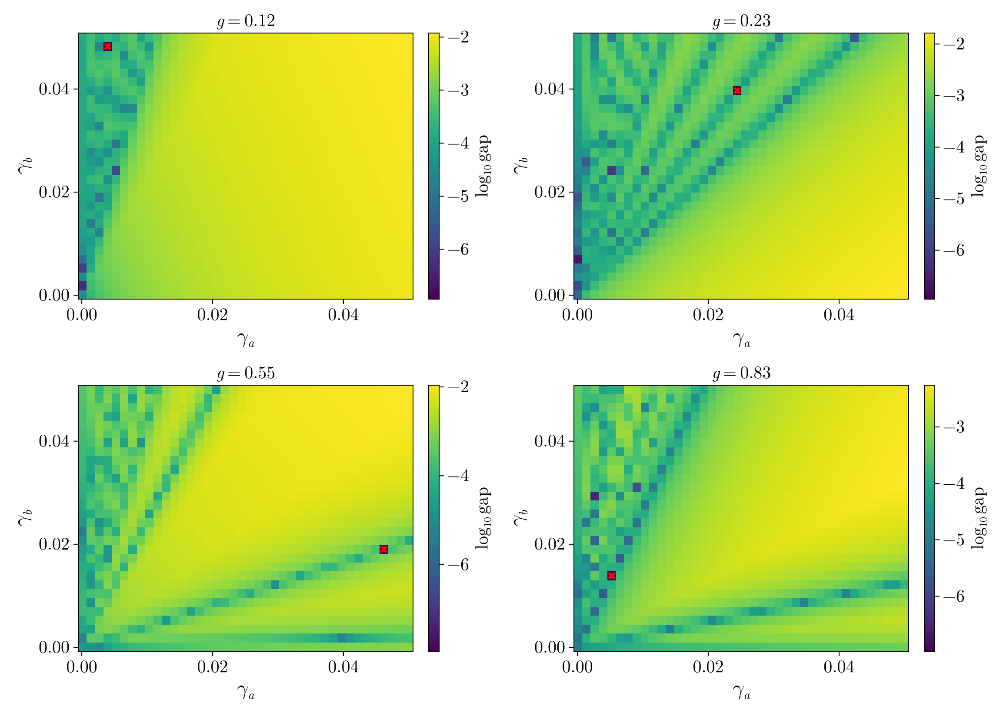

In [ ]:
NT_ep, σ_ep, Nc_ep = 10, 0.1, 40
win_ep = (-0.5, -1e-4, -1.5, 1.5)
vars_r = (ωa = 1.0, ωb = 1.0, Nc = Nc_ep, N = 1)

g_grid  = range(0.01, 1.2, 120) |> collect
γa_grid = range(1e-4, 0.05, 40) |> collect
γb_grid = range(1e-4, 0.05, 30) |> collect
gap3 = fill(NaN, length(g_grid), length(γa_grid), length(γb_grid))

Prog = Progress(length(g_grid))
Threads.@threads for ig in eachindex(g_grid)
    for ia in eachindex(γa_grid), ib in eachindex(γb_grid)
        (γa_grid[ia] == 0 && γb_grid[ib] == 0) && continue
        L = gen_liouvillian_qrm(g_grid[ig], vars_r, [γa_grid[ia], γb_grid[ib]]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
        gap3[ig, ia, ib] = lep_min_gap(L; window = win_ep, exclude_zero = true).gap
    end
    next!(Prog)
end

interior(a, b) = (γa_grid[1] < a < γa_grid[end]) && (γb_grid[1] < b < γb_grid[end])
allc = sort([(gap3[ig,ia,ib], ig, ia, ib) for ig in eachindex(g_grid), ia in eachindex(γa_grid),
             ib in eachindex(γb_grid) if !isnan(gap3[ig,ia,ib])] |> vec; by = first)
println("Glbal minima:   g       γa      γb      gap          γ* inside?")
for (gp, ig, ia, ib) in allc[1:min(8, length(allc))]
    println("  ", rpad(round(g_grid[ig],digits=3),8), rpad(round(γa_grid[ia],digits=4),8),
            rpad(round(γb_grid[ib],digits=4),8), rpad(round(gp,sigdigits=3),13),
            interior(γa_grid[ia], γb_grid[ib]) ? "yes (EP candidate)" : "edge (trivial/DP)")
end

g_slices = nothing        # ex. [0.4, 0.73, 1.0, 1.25] otherwise
if g_slices === nothing
    cand_gidx = unique([c[2] for c in allc if interior(γa_grid[c[3]], γb_grid[c[4]])])
    sidx = Int[]
    for gi in cand_gidx; length(sidx) ≥ 4 && break; push!(sidx, gi); end
    for gi in round.(Int, range(1, length(g_grid), 4))
        length(sidx) ≥ 4 && break; (gi in sidx) || push!(sidx, gi)
    end
    sort!(sidx)
else
    sidx = sort(unique([argmin(abs.(g_grid .- gs)) for gs in g_slices]))
end


fig_3d = Figure(size = (1150, 820))
for (p, ig) in enumerate(sidx)
    r = (p - 1) ÷ 2 + 1; c0 = ((p - 1) % 2) * 2
    S  = gap3[ig, :, :]
    ax = Axis(fig_3d[r, c0+1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b",
              title = L"g = %$(round(g_grid[ig], digits=3))")
    hm = heatmap!(ax, γa_grid, γb_grid, log10.(S); colormap = :viridis)
    Colorbar(fig_3d[r, c0+2], hm; label = L"\log_{10}\mathrm{gap}")
    jm = argmin([isnan(S[i,j]) ? Inf : S[i,j] for i in axes(S,1), j in axes(S,2)])
    scatter!(ax, [γa_grid[jm[1]]], [γb_grid[jm[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("lep_bruteforce_slices.png", fig_3d; px_per_unit = 3)
fig_3d

In [ ]:
NT_ep, σ_ep, Nc_ep = 10, 0.1, 40
win_ep = (-0.5, -1e-4, -1.5, 1.5)
vars_r = (ωa = 1.0, ωb = 1.0, Nc = Nc_ep, N = 1)

g_grid  = range(0.01, 1.2, 200) |> collect
γa_grid = range(1e-4, 0.05, 400) |> collect
γb_grid = range(1e-4, 0.05, 400) |> collect
gap3 = fill(NaN, length(g_grid), length(γa_grid), length(γb_grid))

Prog = Progress(length(g_grid))
Threads.@threads for ig in eachindex(g_grid)
    for ia in eachindex(γa_grid), ib in eachindex(γb_grid)
        (γa_grid[ia] == 0 && γb_grid[ib] == 0) && continue
        L = gen_liouvillian_qrm(g_grid[ig], vars_r, [γa_grid[ia], γb_grid[ib]]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
        gap3[ig, ia, ib] = lep_min_gap(L; window = win_ep, exclude_zero = true).gap
    end
    next!(Prog)
end

interior(a, b) = (γa_grid[1] < a < γa_grid[end]) && (γb_grid[1] < b < γb_grid[end])
allc = sort([(gap3[ig,ia,ib], ig, ia, ib) for ig in eachindex(g_grid), ia in eachindex(γa_grid),
             ib in eachindex(γb_grid) if !isnan(gap3[ig,ia,ib])] |> vec; by = first)
println("Glbal minima:   g       γa      γb      gap          γ* inside?")
for (gp, ig, ia, ib) in allc[1:min(8, length(allc))]
    println("  ", rpad(round(g_grid[ig],digits=3),8), rpad(round(γa_grid[ia],digits=4),8),
            rpad(round(γb_grid[ib],digits=4),8), rpad(round(gp,sigdigits=3),13),
            interior(γa_grid[ia], γb_grid[ib]) ? "yes (EP candidate)" : "edge (trivial/DP)")
end

g_slices = nothing        # ex. [0.4, 0.73, 1.0, 1.25] otherwise
if g_slices === nothing
    cand_gidx = unique([c[2] for c in allc if interior(γa_grid[c[3]], γb_grid[c[4]])])
    sidx = Int[]
    for gi in cand_gidx; length(sidx) ≥ 4 && break; push!(sidx, gi); end
    for gi in round.(Int, range(1, length(g_grid), 4))
        length(sidx) ≥ 4 && break; (gi in sidx) || push!(sidx, gi)
    end
    sort!(sidx)
else
    sidx = sort(unique([argmin(abs.(g_grid .- gs)) for gs in g_slices]))
end


fig_3d = Figure(size = (1150, 820))
for (p, ig) in enumerate(sidx)
    r = (p - 1) ÷ 2 + 1; c0 = ((p - 1) % 2) * 2
    S  = gap3[ig, :, :]
    ax = Axis(fig_3d[r, c0+1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b",
              title = L"g = %$(round(g_grid[ig], digits=3))")
    hm = heatmap!(ax, γa_grid, γb_grid, log10.(S); colormap = :viridis)
    Colorbar(fig_3d[r, c0+2], hm; label = L"\log_{10}\mathrm{gap}")
    jm = argmin([isnan(S[i,j]) ? Inf : S[i,j] for i in axes(S,1), j in axes(S,2)])
    scatter!(ax, [γa_grid[jm[1]]], [γb_grid[jm[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("lep_bruteforce_slices.png", fig_3d; px_per_unit = 3)
fig_3d

Progress: 100%|█████████████████████████████████████████| Time: 4:15:18m37


Glbal minima:   g       γa      γb      gap          γ* inside?
  1.045   0.0047  0.0011  4.51e-11     yes (EP candidate)
  1.009   0.0011  0.0066  1.08e-10     yes (EP candidate)
  0.321   0.0005  0.0135  1.61e-10     yes (EP candidate)
  0.076   0.0005  0.0472  1.64e-10     yes (EP candidate)
  0.811   0.0004  0.0145  1.67e-10     yes (EP candidate)
  0.482   0.005   0.0286  1.67e-10     yes (EP candidate)
  1.009   0.0012  0.0074  2.77e-10     yes (EP candidate)
  0.746   0.0449  0.0077  2.9e-10      yes (EP candidate)


In [ ]:
vars_c = (ωa = 1.0, ωb = 1.0, Nc = 30, N = 1)
NT_c, σ_c, win_c = 12, 0.1, (-0.5, -1e-4, -1.5, 1.5)
g0, γa0, γb0 = 0.764, 0.018, 0.010
Δg, npts = 0.06, 81

buildL(g) = gen_liouvillian_qrm(g, vars_c, [γa0, γb0]; N_trunc = NT_c, σ_filter = σ_c)[3]
r0 = lep_min_gap(buildL(g0); window = win_c, exclude_zero = true, overlap = true)
g_scan = range(g0 - Δg, g0 + Δg, npts) |> collect
tr = track_pair([buildL(g) for g in g_scan], r0.λi, r0.λj)

jmin = argmin(tr.gaps); gstar = g_scan[jmin]
sel = [i for i in eachindex(g_scan) if 2 ≤ abs(i - jmin) ≤ 20]
x = log.(abs.(g_scan[sel] .- gstar)); y = log.(tr.gaps[sel])
pexp = ((x .- sum(x)/length(x)) ⋅ (y .- sum(y)/length(y))) / sum(abs2, x .- sum(x)/length(x))
println("coalescence at g* = ", round(gstar, digits=4), "   loc = ", round(tr.mid[jmin], sigdigits=4))
println("gap_min = ", round(tr.gaps[jmin], sigdigits=3), "   overlap = ", round(tr.overlaps[jmin], digits=4))
println("gap scaling exponent ≈ ", round(pexp, digits=3), "   ⇒ ", pexp < 0.75 ? "EP (√)" : "DP (linear)")

fig_ep2 = Figure(size = (1500, 440))
ax1 = Axis(fig_ep2[1,1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "trajectories (color = g)")
sc = scatter!(ax1, real.(tr.λ1s), imag.(tr.λ1s); color = g_scan, colormap = :viridis, markersize = 7)
scatter!(ax1, real.(tr.λ2s), imag.(tr.λ2s); color = g_scan, colormap = :viridis, markersize = 7, marker = :diamond)
Colorbar(fig_ep2[1,2], sc; label = L"g")
ax2 = Axis(fig_ep2[1,3]; xlabel = L"g", ylabel = "gap", title = L"\mathrm{gap}\propto|g-g^\star|^{%$(round(pexp,digits=2))}")
lines!(ax2, g_scan, tr.gaps; color = :crimson); vlines!(ax2, [gstar]; color = (:black, 0.4), linestyle = :dot)
ax3 = Axis(fig_ep2[1,4]; xlabel = L"g", ylabel = "overlap", title = "eigenvector coalescence")
lines!(ax3, g_scan, tr.overlaps; color = :royalblue); vlines!(ax3, [gstar]; color = (:black, 0.4), linestyle = :dot)

# save("ep_candidate_scan.png", fig_ep2; px_per_unit = 3)
fig_ep2

In [ ]:
Δg_s, npts_s, ncand_s = 0.06, 81, 10
int_cands = [(gp, g_grid[ig], γa_grid[ia], γb_grid[ib])
             for (gp, ig, ia, ib) in allc if interior(γa_grid[ia], γb_grid[ib])]
println("Screening interior candidates:   g0      γa      γb      g*        exp    type")
ep_pass = NamedTuple[]
for (gp0, gc, ac, bc) in int_cands[1:min(ncand_s, length(int_cands))]
    bL(g) = gen_liouvillian_qrm(g, vars_r, [ac, bc]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
    r0 = lep_min_gap(bL(gc); window = win_ep, exclude_zero = true)
    gs = range(gc - Δg_s, gc + Δg_s, npts_s) |> collect
    tr = track_pair([bL(g) for g in gs], r0.λi, r0.λj)
    jm = argmin(tr.gaps); gstar = gs[jm]
    sel = [i for i in eachindex(gs) if 2 ≤ abs(i - jm) ≤ 18]
    x = log.(abs.(gs[sel] .- gstar)); y = log.(tr.gaps[sel])
    pexp = ((x .- sum(x)/length(x)) ⋅ (y .- sum(y)/length(y))) / sum(abs2, x .- sum(x)/length(x))
    tipo = pexp < 0.75 ? "EP?" : "DP"
    pexp < 0.75 && push!(ep_pass, (g = gc, γa = ac, γb = bc, exp = pexp))
    println("  ", rpad(round(gc,digits=3),8), rpad(round(ac,digits=4),8), rpad(round(bc,digits=4),8),
            rpad(round(gstar,digits=4),10), rpad(round(pexp,digits=3),7), tipo)
end
println("\nCandidates passing (exponent < 0.75, √-like): ", length(ep_pass))

In [ ]:
verdict(r) = r.d_swap < 0.3*r.d_same ? "SWAP ⇒ EP" :
             r.d_same < 0.3*r.d_swap ? "no swap ⇒ non-EP" : "ambiguous (no clear swap)"
nθ_e = 240
enc_points = isempty(ep_pass) ? [(g = 0.764, γa = 0.018, γb = 0.010)] : ep_pass
isempty(ep_pass) && println("No candidate passed: running a CONTROL encircling on a known DP.\n")

local sc
fig_enc = Figure(size = (560*length(enc_points) + 80, 560))
for (p, pt) in enumerate(enc_points)
    gc, ac, bc = pt.g, pt.γa, pt.γb
    rg, rγ = 0.03, 0.6*ac
    θe = range(0, 2π, nθ_e) |> collect
    bL2(g, γa) = gen_liouvillian_qrm(g, vars_r, [γa, bc]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
    Ls = [bL2(gc + rg*cos(t), ac + rγ*sin(t)) for t in θe]
    r0 = lep_min_gap(bL2(gc, ac); window = win_ep, exclude_zero = true)
    res = encircle_swap(Ls, r0.λi, r0.λj)
    println("(g=", round(gc,digits=3), ", γa=", round(ac,digits=4), "): d_swap/d_same = ",
            round(res.d_swap/res.d_same, digits=3), "  → ", verdict(res))
    ax = Axis(fig_enc[1, p]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda",
              title = L"g=%$(round(gc,digits=3)),\ \gamma_a=%$(round(ac,digits=3))")
    sc = scatter!(ax, real.(res.tr.λ1s), imag.(res.tr.λ1s); color = θe, colormap = :plasma, markersize = 6)
    scatter!(ax, real.(res.tr.λ2s), imag.(res.tr.λ2s); color = θe, colormap = :plasma, markersize = 6, marker = :diamond)
    scatter!(ax, [real(r0.λi), real(r0.λj)], [imag(r0.λi), imag(r0.λj)]; color = :black, marker = :star5, markersize = 12)
end
Colorbar(fig_enc[1, length(enc_points)+1], sc; label = L"\theta")

# save("ep_encirclement.png", fig_enc; px_per_unit = 3)
fig_enc

In [82]:
function block_mat(g, ωb, κ; Nc=24, q=1)
    E,U,L = gen_liouvillian_qrm(g,(ωa=1.0,ωb=ωb,Nc=Nc,N=1),[κ,0.0]; N_trunc=NTb, σ_filter=σb)
    Πb = to_dense(kron(Qobj(diagm((-1.0).^(0:Nc-1))), sigmaz())).data
    πd = sign.(real.(diag(U.data' * Πb * U.data)))
    charge = [πd[a]*πd[b] for b in 1:NTb for a in 1:NTb]
    Lm = Matrix(L.data); ip=findall(≈(1),charge); im=findall(≈(-1),charge)
    (block = Lm[q==1 ? ip : im, q==1 ? ip : im], offblock = norm(Lm[ip,im])/norm(Lm))
end

gapb(g,ωb,κ,q,win) = ep_feshbach(block_mat(g,ωb,κ;q=q).block; window=win).gap

function loc(g0,w0,κ,q,win; rounds=12, R0=0.02)
    g,w,R=g0,w0,R0
    for _ in 1:rounds
        gg=range(g-R,g+R,9);ww=range(w-R,w+R,9); M=[gapb(gx,wx,κ,q,win) for wx in ww,gx in gg]
        jm=argmin(M); g=gg[jm[2]]; w=ww[jm[1]]; R/=2.2
    end
    g,w
end

loc (generic function with 1 method)

block-diagonalità (off-block/‖L‖) = 0.0
κ=0.1: gap minimo su (g,ωb) nel blocco = 3.4e-5  (floora ~3e-5; l'EP parità-rotto arriva a ~1e-8) → nessun EP a κ fisso

κ-scaling della near-degeneracy (DP ⇔ gap∝κ², t∝κ):
κ      gap        t          gap/κ²    t/κ
0.1    3.4e-5     0.007841   0.0034    0.0784
0.05   8.48e-6    0.003992   0.00339   0.0798
0.02   1.35e-6    0.001605   0.00339   0.0802
0.01   3.39e-7    0.0008029  0.00339   0.0803
⇒ gap∝κ^2.0, t∝κ^0.99 → M2→scalare → DIABOLIC POINT


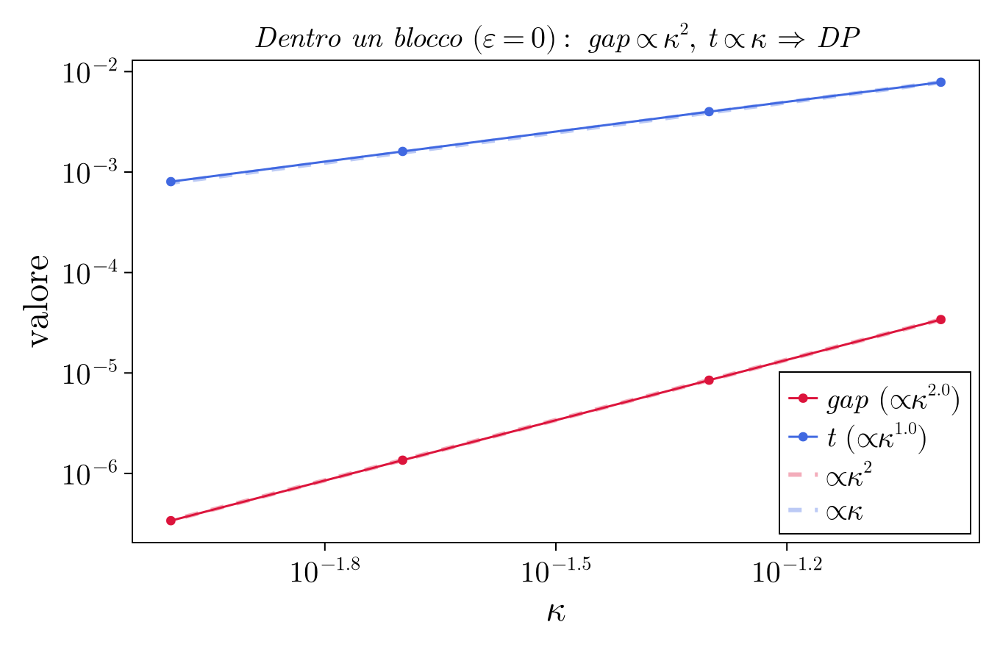

In [ ]:
NTb, σb = 12, 10.0

q=1; win=(-0.5,-1e-4,-0.15,0.15)
println("block-diagonality (off-block/‖L‖) = ", round(block_mat(0.48,0.95,0.1;q=q).offblock, sigdigits=3))
# Step (1): the gap reaches a floor at fixed κ (no coalescence → no EP)
gf,wf = loc(0.48,0.95,0.1,q,win)
println("κ=0.1: minimum gap over (g,ωb) within the block = ", round(gapb(gf,wf,0.1,q,win),sigdigits=3),
        "  (floor ~3e-5; the parity-broken EP reaches ~1e-8) → no EP at fixed κ")
# Step (2): κ-scaling → DP (gap∝κ², t∝κ)
κs=[0.1,0.05,0.02,0.01]; gaps=Float64[]; ts=Float64[]
println("\nκ-scaling of the near-degeneracy (DP ⇔ gap∝κ², t∝κ):")
println("κ      gap        t          gap/κ²    t/κ")
for κ in κs
    g,w = loc(0.48,0.95,κ,q,win); r = ep_feshbach(block_mat(g,w,κ;q=q).block; window=win)
    push!(gaps,r.gap); push!(ts,r.t)
    println(rpad(κ,7),rpad(round(r.gap,sigdigits=3),11),rpad(round(r.t,sigdigits=4),11),
            rpad(round(r.gap/κ^2,sigdigits=3),10),round(r.t/κ,sigdigits=3))
end
sg=(log(gaps[end])-log(gaps[1]))/(log(κs[end])-log(κs[1])); st=(log(ts[end])-log(ts[1]))/(log(κs[end])-log(κs[1]))
println("⇒ gap∝κ^",round(sg,digits=2),", t∝κ^",round(st,digits=2)," → M2→scalar → DIABOLIC POINT")

fig_wb = Figure(size=(680,440))
ax = Axis(fig_wb[1,1]; xlabel=L"\kappa", ylabel="value", xscale=log10, yscale=log10,
          title=L"Within\ a\ block\ (\varepsilon=0):\ gap\propto\kappa^2,\ t\propto\kappa\ \Rightarrow\ DP")
scatterlines!(ax, κs, gaps; color=:crimson,   markersize=9, label=L"gap\ (\propto\kappa^{%$(round(sg,digits=1))})")
scatterlines!(ax, κs, ts;   color=:royalblue, markersize=9, label=L"t\ (\propto\kappa^{%$(round(st,digits=1))})")
lines!(ax, κs, gaps[1].*(κs./κs[1]).^2; color=(:crimson,0.35),   linestyle=:dash, label=L"\propto\kappa^2")
lines!(ax, κs, ts[1].*(κs./κs[1]);      color=(:royalblue,0.35), linestyle=:dash, label=L"\propto\kappa")
axislegend(ax; position=:rb)

# save("ep_within_block.png", fig_wb; px_per_unit=3)
fig_wb

# Symmetry-breaking QRM

In [84]:
Lof(g, ωb, ε) = gen_liouvillian_qrm(g, (ωa=1.0, ωb=ωb, Nc=20, N=1), [γa, 0.0]; ε = ε, N_trunc = NT_e, σ_filter = σ_e)[3]

function gapf(g, ωb, ε)
    v = eigvals(Matrix(Lof(g, ωb, ε).data))
    w = filter(λ -> winF[1]≤real(λ)≤winF[2] && winF[3]≤imag(λ)≤winF[4], v)
    length(w) < 2 && return Inf
    b = Inf; for i in 1:length(w)-1, j in i+1:length(w); b = min(b, abs(w[i]-w[j])); end; b
end

function ep_at(ε; gbox=(0.35,0.62), wbox=(0.95,1.28))
    gg=range(gbox...,13); ww=range(wbox...,13); M=[gapf(gx,wx,ε) for wx in ww, gx in gg]
    jm=argmin(M); g=gg[jm[2]]; w=ww[jm[1]]; R=0.03
    for _ in 1:5
        gg=range(g-R,g+R,9); ww=range(w-R,w+R,9); M=[gapf(gx,wx,ε) for wx in ww, gx in gg]
        jm=argmin(M); g=gg[jm[2]]; w=ww[jm[1]]; R/=2.5
    end
    (g=g, ωb=w, r=ep_feshbach(Lof(g,w,ε); window=winF))
end

ep_at (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:20


ε=0.2: EP a g=0.3192 ωb=1.0361 → EP2 (dim ker = 1: only 1 SV → 0)  (t=0.000603, t/gap=522.4)

Certificazione EP per vari ε:
ε      g_EP     ωb_EP    gap        t          t/gap    verdetto
0.1   0.4625   1.1387   4.4e-5     0.01447    329.1    EP2 (dim ker = 1: only 1 SV → 0)
0.2   0.3192   1.0361   1.15e-6    0.000603   522.4    EP2 (dim ker = 1: only 1 SV → 0)
0.3   0.4231   1.2718   2.02e-6    0.001835   907.0    EP2 (dim ker = 1: only 1 SV → 0)
0.4   0.3716   1.1039   4.2e-5     0.02315    551.2    EP2 (dim ker = 1: only 1 SV → 0)


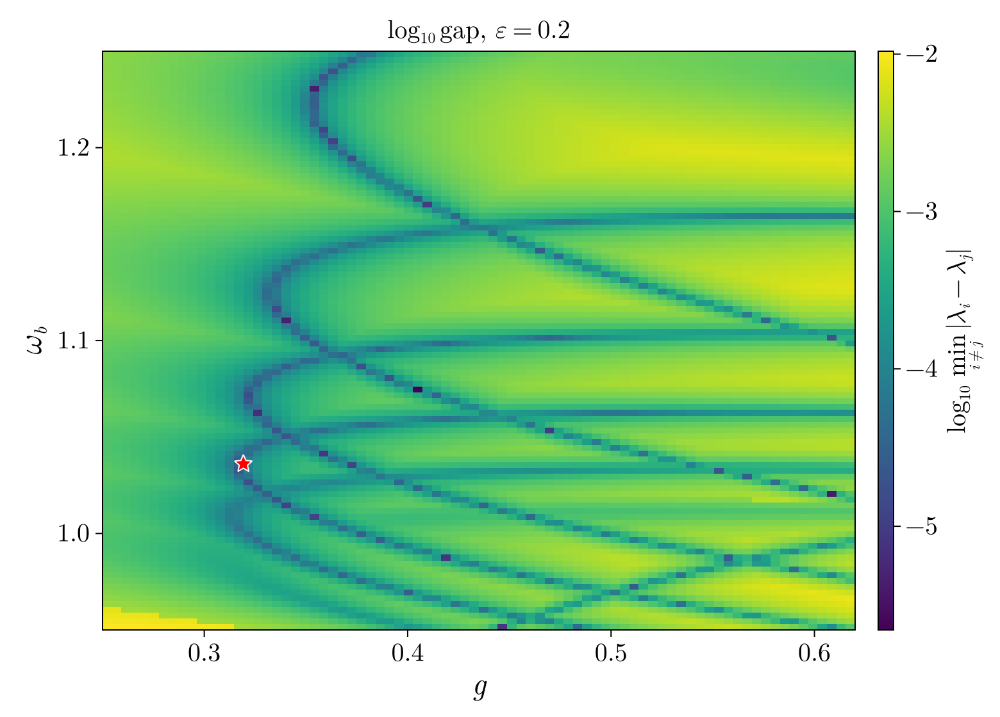

In [ ]:
NT_e, σ_e, γa = 14, 10.0, 0.1
winF = (-0.6, -0.02, -1.5, 1.5)

ε0 = 0.2
g_grid_ep = range(0.25, 0.62, 100) |> collect
ωb_grid_ep = range(0.95, 1.25, 80) |> collect

Gmap = fill(NaN, length(g_grid_ep), length(ωb_grid_ep))
Prog = Progress(length(g_grid_ep))
Threads.@threads for ig in eachindex(g_grid_ep)
    for iw in eachindex(ωb_grid_ep)
        Gmap[ig, iw] = gapf(g_grid_ep[ig], ωb_grid_ep[iw], ε0)
    end
    next!(Prog)
end
# Gmap = [gapf(g, ωb, ε0) for ωb in ωb_grid_ep, g in g_grid_ep]
ep = ep_at(ε0)
println("ε=$ε0: EP at g=$(round(ep.g,digits=4)) ωb=$(round(ep.ωb,digits=4)) → ", ep.r.verdict,
        "  (t=$(round(ep.r.t,sigdigits=3)), t/gap=$(round(ep.r.tratio,sigdigits=4)))")

fig_ep = Figure(size=(780,560))
ax = Axis(fig_ep[1,1]; xlabel=L"g", ylabel=L"\omega_b", title=L"\log_{10}\mathrm{gap},\ \varepsilon=%$(ε0)")
hm = heatmap!(ax, g_grid_ep, ωb_grid_ep, permutedims(log10.(Gmap)); colormap=:viridis)
Colorbar(fig_ep[1,2], hm; label=L"\log_{10}\,\min_{i\neq j}|\lambda_i-\lambda_j|")
scatter!(ax, [ep.g], [ep.ωb]; color=:red, marker=:star5, markersize=16, strokecolor=:white, strokewidth=1)
# save("ep_parity_broken.png", fig_ep; px_per_unit=3)

println("\nEP certification for varying ε:")
println("ε      g_EP     ωb_EP    gap        t          t/gap    verdict")
for ε in [0.1, 0.2, 0.3, 0.4]
    e = ep_at(ε); r = e.r
    println(rpad(ε,6), rpad(round(e.g,digits=4),9), rpad(round(e.ωb,digits=4),9),
            rpad(round(r.gap,sigdigits=3),11), rpad(round(r.t,sigdigits=4),11),
            rpad(round(r.tratio,sigdigits=4),9), r.verdict)
end

fig_ep

In [ ]:
# Newton continuation of the EP in ε: track the same pair and apply Newton to δ²=((λ1-λ2)/2)²=0.
NcN, NTN, κN, σN = 24, 14, 0.1, 10.0
LN(g,ωb,ε) = gen_liouvillian_qrm(g,(ωa=1.0,ωb=ωb,Nc=NcN,N=1),[κN,0.0]; ε=ε, N_trunc=NTN, σ_filter=σN)[3]
function pair_d2(g,ωb,ε,λref)                       # pair closest to λref + δ²
    v = eigvals(Matrix(LN(g,ωb,ε).data)); idx = sortperm(abs.(v .- λref))
    v[idx[1]], v[idx[2]], ((v[idx[1]]-v[idx[2]])/2)^2
end
function newton_ep(g,ωb,ε,λref; iters=20, h=1e-5)   # 2-knob Newton on δ²(g,ωb)=0
    for _ in 1:iters
        _,_,f=pair_d2(g,ωb,ε,λref); _,_,fg=pair_d2(g+h,ωb,ε,λref); _,_,fw=pair_d2(g,ωb+h,ε,λref)
        Jg=(fg-f)/h; Jw=(fw-f)/h; J=[real(Jg) real(Jw); imag(Jg) imag(Jw)]
        s = J \ [-real(f); -imag(f)]; nrm=norm(s); nrm>0.03 && (s .*= 0.03/nrm)
        g+=s[1]; ωb+=s[2]; λ1,λ2,_=pair_d2(g,ωb,ε,λref); λref=(λ1+λ2)/2; norm(s)<1e-12 && break
    end
    λ1,λ2,_ = pair_d2(g,ωb,ε,λref); (g,ωb,(λ1+λ2)/2, abs(λ1-λ2))
end

newton_ep (generic function with 2 methods)

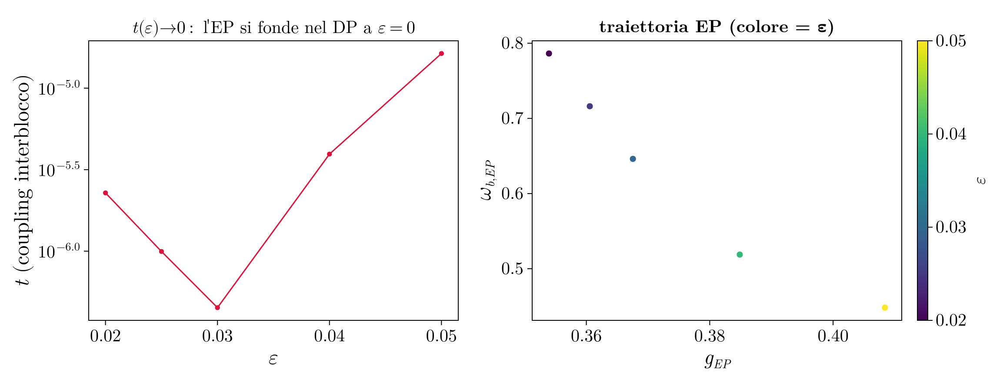

In [ ]:
εa=Float64[]; ga=Float64[]; wa=Float64[]; ta=Float64[]
let hist = Tuple{Float64,Float64,Float64,ComplexF64}[]
    g,w,λ,_ = newton_ep(0.454,1.019,0.20,-0.195+0im); push!(hist,(0.20,g,w,λ))
    g,w,λ,_ = newton_ep(g,w,0.195,λ);                 push!(hist,(0.195,g,w,λ))
    for ε in 0.19:-0.005:0.02
        (ε1,g1,w1,λ1)=hist[end]; (ε0,g0,w0,λ0)=hist[end-1]; rp=(ε-ε1)/(ε1-ε0)
        gp=g1+rp*(g1-g0); wp=w1+rp*(w1-w0); λp=λ1+rp*(λ1-λ0)   # linear predictor
        g,w,λ,gap = newton_ep(gp,wp,ε,λp)                       # Newton corrector
        rr = ep_feshbach(LN(g,w,ε); window=(real(λ)-0.04,real(λ)+0.04,imag(λ)-0.04,imag(λ)+0.04))
        push!(hist,(ε,g,w,λ))
        gap < 1e-5 && (push!(εa,ε); push!(ga,g); push!(wa,w); push!(ta,rr.t))   # keep well-converged points
    end
end

fig_cont = Figure(size=(1150,440))
ax1 = Axis(fig_cont[1,1]; xlabel=L"\varepsilon", ylabel=L"t\ \mathrm{(inter-block\ coupling)}",
           yscale=log10, title=L"t(\varepsilon)\to 0:\ \mathrm{the\ EP\ merges\ into\ the\ DP\ at}\ \varepsilon=0")
scatterlines!(ax1, εa, ta; color=:crimson, markersize=8)
ax2 = Axis(fig_cont[1,2]; xlabel=L"g_{EP}", ylabel=L"\omega_{b,EP}", title="EP trajectory (color = ε)")
sc = scatter!(ax2, ga, wa; color=εa, colormap=:viridis, markersize=10)
Colorbar(fig_cont[1,3], sc; label=L"\varepsilon")
# save("ep_continuity.png", fig_cont; px_per_unit=3)
fig_cont

n   ε     g_EP     ωb_EP    λ*        gap        t          svratio    verdetto
1   0.22  0.6251   1.1433   -0.0906   2.28e-6    0.01369    1.19e8     EP2 ✓
2   0.2   0.4329   1.0341   -0.1953   2.55e-7    0.001224   9.98e7     EP2 ✓
3   0.2   0.3522   1.052    -0.2967   6.3e-7     0.0005196  3.29e6     EP2 ✓


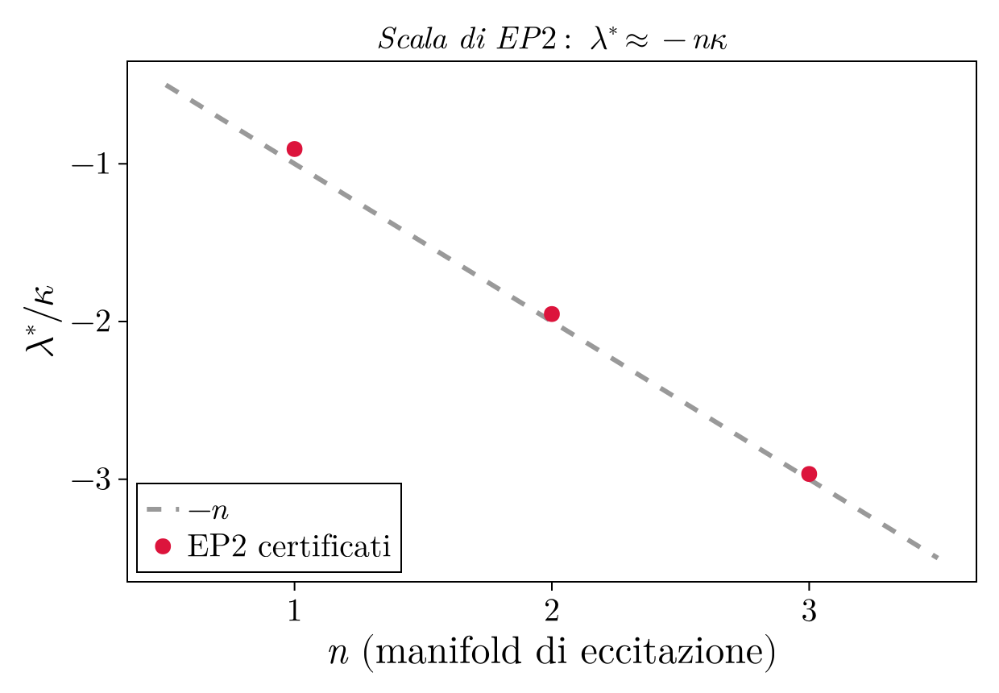

In [ ]:
# The 3 families of EP2s (scale λ*≈-nκ), certified with Feshbach (NT=14).
NcF, NTF, κF, σF = 24, 14, 0.1, 10.0
LRf(g,w,ε) = gen_liouvillian_qrm(g,(ωa=1.0,ωb=w,Nc=NcF,N=1),[κF,0.0]; ε=ε, N_trunc=NTF, σ_filter=σF)[3]
function gapf_ep(g,w,ε,win)                        # lightweight gap for localization
    v = eigvals(Matrix(LRf(g,w,ε).data))
    w2 = filter(λ -> win[1]≤real(λ)≤win[2] && win[3]≤imag(λ)≤win[4], v); length(w2)<2 && return Inf
    b=Inf; for i in 1:length(w2)-1, j in i+1:length(w2); b=min(b,abs(w2[i]-w2[j])); end; b
end
function certify_ep(g0,w0,ε,λ0; rounds=10, δ=0.03) # drive (g,ωb)→gap 0, then certify
    win=(real(λ0)-δ,real(λ0)+δ,imag(λ0)-δ,imag(λ0)+δ); g,w,R=g0,w0,0.03
    for _ in 1:rounds
        gg=range(g-R,g+R,9); ww=range(w-R,w+R,9); M=[gapf_ep(gx,wx,ε,win) for wx in ww, gx in gg]
        jm=argmin(M); g=gg[jm[2]]; w=ww[jm[1]]; R/=2.2
    end
    (g=g, ωb=w, r=ep_feshbach(LRf(g,w,ε); window=win))
end

seeds = [(1,0.22,0.625,1.143,-0.091+0im), (2,0.20,0.434,1.033,-0.195+0im), (3,0.20,0.355,1.048,-0.297+0im)]
ns=Int[]; λs=Float64[]
println("n   ε     g_EP     ωb_EP    λ*        gap        t          svratio    verdict")
for (n,ε,g0,w0,λ0) in seeds
    e = certify_ep(g0,w0,ε,λ0); r = e.r
    push!(ns,n); push!(λs, real(r.λ))
    println(rpad(n,4), rpad(ε,6), rpad(round(e.g,digits=4),9), rpad(round(e.ωb,digits=4),9),
            rpad(round(real(r.λ),digits=4),10), rpad(round(r.gap,sigdigits=3),11),
            rpad(round(r.t,sigdigits=4),11), rpad(round(r.svratio,sigdigits=3),11),
            occursin("EP2", r.verdict) ? "EP2 ✓" : "?")
end

fig_lad = Figure(size=(620,430))
ax = Axis(fig_lad[1,1]; xlabel=L"n\ \mathrm{(excitation\ manifold)}", ylabel=L"\lambda^*/\kappa",
          title=L"EP2\ scale:\ \lambda^*\approx -n\kappa")
lines!(ax, [0.5,3.5], [-0.5,-3.5]; color=(:black,0.4), linestyle=:dash, label=L"-n")
scatter!(ax, ns, λs ./ κF; color=:crimson, markersize=14, label="certified EP2s")
axislegend(ax; position=:lb)
# save("ep_ladder.png", fig_lad; px_per_unit=3)
fig_lad

n | svratio     | √-exp VICINO [1e-6,1e-5] | √-exp LONTANO [1e-4,1e-3]
1 | 8.33e11      | 0.499                    | 0.377
2 | 1.21e11      | 0.4971                   | 0.074
3 | 4.0e8        | 0.5049                   | 0.738


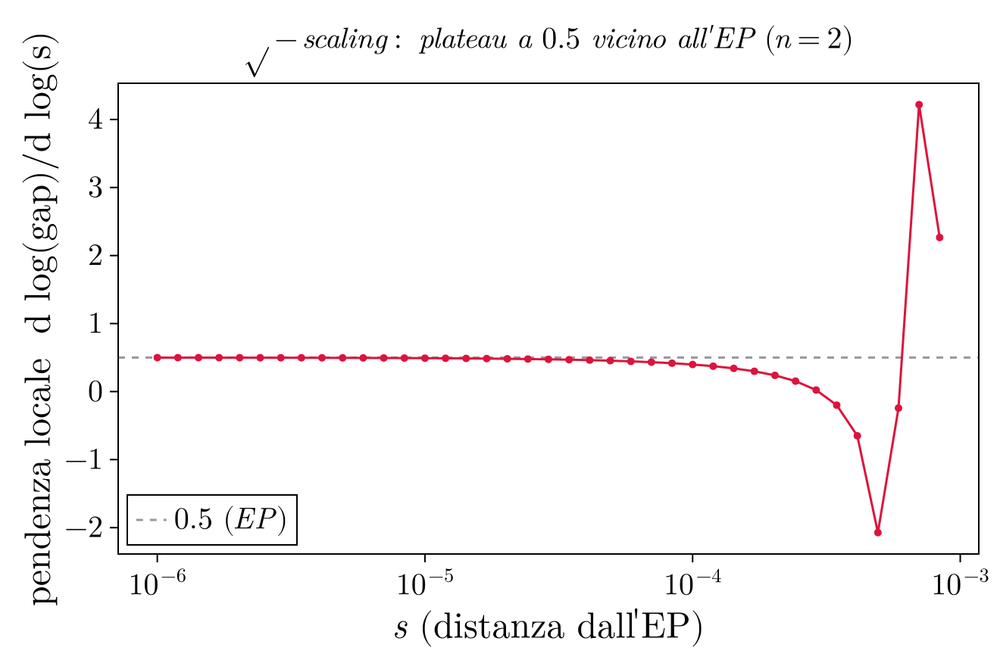

In [ ]:
# √-scaling DONE RIGHT: deep Newton + fit in the window NEAR the EP (→0.5), vs. far away (spurious).
NcS, NTS, κS = 24, 14, 0.1
LS(g,w,ε) = gen_liouvillian_qrm(g,(ωa=1.0,ωb=w,Nc=NcS,N=1),[κS,0.0]; ε=ε, N_trunc=NTS, σ_filter=10.0)[3]
function pdS(g,w,ε,λref)                              # tracked pair + δ² for Newton
    v=eigvals(Matrix(LS(g,w,ε).data)); idx=sortperm(abs.(v .- λref))
    v[idx[1]], v[idx[2]], ((v[idx[1]]-v[idx[2]])/2)^2
end
function newtonS(g,w,ε,λref; it=40, h=1e-6)            # deep localization (gap≲1e-8)
    for _ in 1:it
        _,_,f=pdS(g,w,ε,λref);_,_,fg=pdS(g+h,w,ε,λref);_,_,fw=pdS(g,w+h,ε,λref)
        Jg=(fg-f)/h;Jw=(fw-f)/h;J=[real(Jg) real(Jw);imag(Jg) imag(Jw)]
        s=J\[-real(f);-imag(f)];nrm=norm(s);nrm>0.02&&(s.*=0.02/nrm)
        g+=s[1];w+=s[2];λ1,λ2,_=pdS(g,w,ε,λref);λref=(λ1+λ2)/2;norm(s)<1e-14&&break
    end
    λ1,λ2,_=pdS(g,w,ε,λref);(g,w,(λ1+λ2)/2,abs(λ1-λ2))
end
gcut(g,w,ε,λ,s) = (d=1/sqrt(2); abs(pdS(g+s*d,w+s*d,ε,λ)[1]-pdS(g+s*d,w+s*d,ε,λ)[2]))
function expfit(g,w,ε,λ,ss)
    gp=[gcut(g,w,ε,λ,s) for s in ss]; x=log.(ss); y=log.(gp)
    ((x.-sum(x)/length(x))⋅(y.-sum(y)/length(y)))/sum(abs2,x.-sum(x)/length(x))
end

seedsS=[(1,0.22,0.625,1.143,-0.091+0im),(2,0.20,0.434,1.033,-0.195+0im),(3,0.20,0.355,1.048,-0.297+0im)]
println("n | svratio     | √-exp NEAR [1e-6,1e-5] | √-exp FAR [1e-4,1e-3]")
locs = NamedTuple[]
for (n,ε,g0,w0,λ0) in seedsS
    g,w,λ,gap = newtonS(g0,w0,ε,λ0); push!(locs,(n=n,g=g,w=w,ε=ε,λ=λ))
    r = ep_feshbach(LS(g,w,ε); window=(real(λ)-0.03,real(λ)+0.03,imag(λ)-0.03,imag(λ)+0.03))
    pn = expfit(g,w,ε,λ, 10.0.^range(-6,-5,24))       # NEAR (24 points)
    pf = expfit(g,w,ε,λ, 10.0.^range(-4,-3,24))       # FAR
    println(rpad(n,2),"| ",rpad(round(r.svratio,sigdigits=3),12)," | ",
            rpad(round(pn,digits=4),24)," | ",round(pf,digits=3))
end

# Plot: local slope vs. s for n=2 -> plateau at 0.5 nearby, degradation farther away
p2=locs[2]; ss=10.0.^range(-6,-3,40); gp=[gcut(p2.g,p2.w,p2.ε,p2.λ,s) for s in ss]
sl=[log(gp[i+1]/gp[i])/log(ss[i+1]/ss[i]) for i in 1:length(ss)-1]
fig_sc = Figure(size=(660,440))
ax = Axis(fig_sc[1,1]; xlabel=L"s\ \mathrm{(distance\ from\ EP)}", ylabel="local slope  d log(gap)/d log(s)",
          xscale=log10, title=L"√-scaling:\ plateau\ at\ 0.5\ near\ the\ EP\ (n=2)")
hlines!(ax, [0.5]; color=(:black,0.4), linestyle=:dash, label=L"0.5\ (EP)")
scatterlines!(ax, ss[1:end-1], sl; color=:crimson, markersize=7)
axislegend(ax; position=:lb)
# save("ep_scaling_check.png", fig_sc; px_per_unit=3)
fig_sc

κ=0.05:  n   g_EP     ωb_EP    λ*         svratio    λ*/κ     (rif. κ=0.1)
         1   0.5914   1.0946   -0.04539   3.06e8     -0.908   (-0.906)  EP2 ✓
         2   0.4341   1.0324   -0.09762   7.14e8     -1.952   (-1.953)  EP2 ✓
         3   0.4029   1.0071   -0.14829   661000.0   -2.966   (-2.967)  EP2 ✓


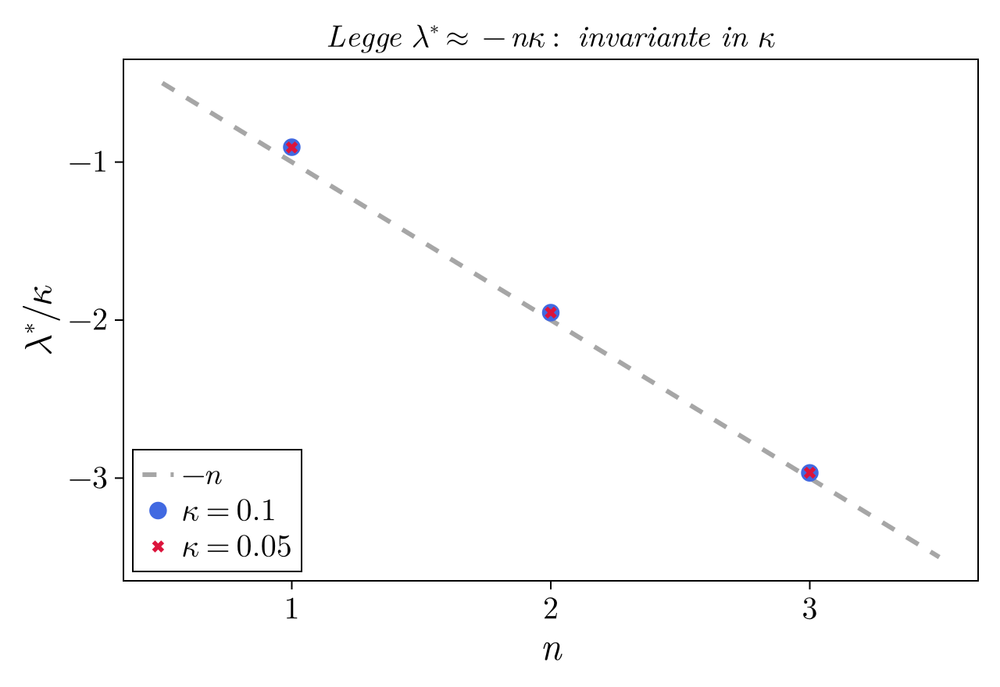

In [ ]:
# Verify the law λ*≈-nκ: repeat the search at κ=0.05 and compare λ*/κ with κ=0.1.
κ2, NcK, NTK, σK = 0.05, 24, 14, 10.0
LK(g,w,ε) = gen_liouvillian_qrm(g,(ωa=1.0,ωb=w,Nc=NcK,N=1),[κ2,0.0]; ε=ε, N_trunc=NTK, σ_filter=σK)[3]
function gapfK(g,w,ε,win)
    v = eigvals(Matrix(LK(g,w,ε).data))
    w2 = filter(λ -> win[1]≤real(λ)≤win[2] && win[3]≤imag(λ)≤win[4], v); length(w2)<2 && return Inf
    b=Inf; for i in 1:length(w2)-1, j in i+1:length(w2); b=min(b,abs(w2[i]-w2[j])); end; b
end
function certK(g0,w0,ε,λ0; rounds=11, δ=0.02)
    win=(real(λ0)-δ,real(λ0)+δ,imag(λ0)-δ,imag(λ0)+δ); g,w,R=g0,w0,0.04
    for _ in 1:rounds
        gg=range(g-R,g+R,9); ww=range(w-R,w+R,9); M=[gapfK(gx,wx,ε,win) for wx in ww, gx in gg]
        jm=argmin(M); g=gg[jm[2]]; w=ww[jm[1]]; R/=2.1
    end
    (g=g, ωb=w, r=ep_feshbach(LK(g,w,ε); window=win))
end

# Seeds (g,ωb,ε) from κ=0.1; predicted λ = -n·κ = -n·0.05
seedsK = [(1,0.22,0.625,1.143,-0.045+0im), (2,0.20,0.434,1.033,-0.098+0im), (3,0.20,0.355,1.048,-0.148+0im)]
ref01 = [-0.906, -1.953, -2.967]           # λ*/κ at κ=0.1 (previous cell)
nsK=Int[]; ratK=Float64[]
println("κ=0.05:  n   g_EP     ωb_EP    λ*         svratio    λ*/κ     (ref. κ=0.1)")
for (k,(n,ε,g0,w0,λ0)) in enumerate(seedsK)
    e = certK(g0,w0,ε,λ0); r = e.r; rat = real(r.λ)/κ2
    push!(nsK,n); push!(ratK,rat)
    println("         ", rpad(n,4), rpad(round(e.g,digits=4),9), rpad(round(e.ωb,digits=4),9),
            rpad(round(real(r.λ),digits=5),11), rpad(round(r.svratio,sigdigits=3),11),
            rpad(round(rat,digits=3),9), "(", ref01[k], ")  ", occursin("EP2",r.verdict) ? "EP2 ✓" : "?")
end

fig_law = Figure(size=(640,440))
ax = Axis(fig_law[1,1]; xlabel=L"n", ylabel=L"\lambda^*/\kappa",
          title=L"Law\ \lambda^*\approx -n\kappa:\ invariant\ under\ \kappa")
lines!(ax, [0.5,3.5], [-0.5,-3.5]; color=(:black,0.35), linestyle=:dash, label=L"-n")
scatter!(ax, [1,2,3], ref01; color=:royalblue, markersize=16, marker=:circle, label=L"\kappa=0.1")
scatter!(ax, nsK, ratK;      color=:crimson,   markersize=11, marker=:xcross, label=L"\kappa=0.05")
axislegend(ax; position=:lb)
# save("ep_law_kappa.png", fig_law; px_per_unit=3)
fig_law